# Resultados de mitigación de sesgo

Compara **LAMDA clásico**, **Fair-GAD** y **Fair-MAD** sobre el conjunto de test, con los mecanismos de equidad congelados tras el entrenamiento.

El notebook está organizado para **ejecutarse una sola vez de arriba abajo**: un único barrido sobre el panel completo alimenta todas las tablas y figuras. No hay celdas que deban repetirse cambiando el conjunto.

Salidas que genera:

| Salida | Contenido |
|---|---|
| `tabla_parametros_fijos` | parte fija de la configuración |
| `chk_df` | esquema por bloques derivado por conjunto |
| `tabla_modelos_binarios`, `tabla_modelos_multiclase` | los tres modelos por conjunto |
| `resumen_mitigacion` | efecto de la mitigación en el panel |
| `figuras/compromiso_*.png` | compromiso rendimiento-equidad |
| `figuras/descriptores_*.png` | descriptores penalizados por Fair-MAD |
| `resumen_descriptores` | separación de los pesos respecto de la unidad |
| `figuras/evolucion_*.png` | evolución por bloques en entrenamiento |
| `figuras/confusion_*.png` | matrices de confusión |
| `sensibilidad`, `calibracion` | sensibilidad de la composición e intensidad |

> **Antes de ejecutar: reinicia el kernel.** Python cachea los módulos ya importados, de modo que un kernel abierto desde antes de modificar `config.py` o los módulos del paquete seguirá usando la versión anterior. Si `datasets_activos()` no devuelve el panel esperado, esa es la causa.

## Señal de control direccional

Fair-GAD emplea una señal de control con signo, indexada por par de grupo y clase, en lugar de la disparidad simétrica agregada por grupo. Con un atributo sensible binario, la disparidad simétrica es idéntica en ambos grupos por antisimetría de las métricas que la componen, de modo que la penalización resultaba una constante igual para todo individuo. La señal direccional solo es positiva cuando el grupo está sobreasignado a la clase, y por tanto distingue entre el grupo favorecido y el desfavorecido.

La disparidad simétrica se conserva como magnitud de reporte: su invarianza entre grupos es correcta para una medida, ya que describe una propiedad de la pareja formada por el modelo y la población.

Fair-MAD mantiene la señal simétrica. Su mecanismo produce un peso único y global por descriptor, aplicado a todos los individuos con independencia de su grupo, de modo que la dirección de la disparidad no tiene destinatario al que aplicarse. La comprobación empírica lo confirma: con señal direccional, Fair-MAD degrada de forma acusada el impacto dispar de COMPAS. Ambos modos quedan disponibles en el parámetro correspondiente para el análisis de sensibilidad.


In [14]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lamda.experiments import runner
from lamda.experiments import config as cfg
from lamda.fairness.disparity import FairnessThresholds, FairnessWeights

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)


## Panel de configuración

Todos los parámetros del experimento se fijan aquí. Ninguna función del motor impone valores: el notebook mantiene el control completo de la configuración.

### Composición de la disparidad agregada

`D_g` se construye combinando las violaciones de umbral de SPD, EOD y DI simétrico, ponderadas por `PESOS`. Esta señal cumple dos funciones simultáneas: se reporta como medida de disparidad y **gobierna la intensidad de la penalización** de Fair-GAD y Fair-MAD. Modificarla, por tanto, no cambia solo lo que se mide, sino también el objetivo que la mitigación persigue.

Dos advertencias metodológicas antes de usar la composición por conjunto:

1. **La composición debe fijarse antes de observar los resultados** y justificarse a priori (por ejemplo, alineándola con la métrica que reporta el trabajo con el que se compara). Elegirla después de ver qué configuración favorece a las propuestas invalidaría la comparación.
2. **La comparabilidad externa no depende de esta composición.** Las métricas que se contrastan con la literatura (SPD, EOD, DI) se calculan y reportan siempre por separado, con independencia de qué entre en `D_g`.

### Normalización

Sin normalizar, `D_g` es una suma ponderada, de modo que una composición de tres métricas produce valores sistemáticamente mayores que una de dos. Esto tiene dos consecuencias: las disparidades dejan de ser comparables entre configuraciones y entre tareas (el perfil binario emplea tres componentes y el multiclase dos), y la intensidad efectiva de la penalización, que es proporcional a `lambda · D_g`, cambia al cambiar la composición.

Con `NORMALIZAR_DISPARIDAD = True` la disparidad se divide por la suma de pesos activos y queda en una escala común. **Al activarla conviene recalibrar `LAMBDA_FAIR` y `ETA_FAIR`**, ya que la señal se reduce aproximadamente en un factor igual al número de métricas empleadas.

In [15]:
# =========================================================
# 1. MODELO BASE
# =========================================================
ALPHA    = 0.65          # parámetro de exigencia
OPERATOR = "minmax"      # "product" | "minmax" | "lukasiewicz"

# =========================================================
# 2. UMBRALES DE EQUIDAD (convenciones de la literatura)
# =========================================================
THRESHOLDS = FairnessThresholds(spd=0.1, eod=0.1, di=0.8)

# =========================================================
# 3. COMPOSICIÓN DE LA DISPARIDAD D_g
# =========================================================
NORMALIZAR_DISPARIDAD = True     # divide D_g por la suma de pesos activos
CLASS_AGGREGATION     = "mean"   # "mean" | "max" (agregación sobre clases)

# Composición por defecto. Peso 0 desactiva la métrica.
COMPOSICION_DEFECTO = {"spd": 1.0, "eod": 1.0, "di": 1.0}

# Composición específica por conjunto. Debe justificarse a priori.
# DI no está definido de forma natural en multiclase: se desactiva (di=0).
COMPOSICION_POR_DATASET = {
    "adult":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "dutch":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "compas":      {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "oulad":       {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "communities": {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "student":     {"spd": 1.0, "eod": 1.0, "di": 0.0},
}

# =========================================================
# 4. AYUDAS DE CONFIGURACIÓN
# =========================================================
def pesos_de(dataset: str) -> FairnessWeights:
    """Devuelve los pesos de composición de D_g aplicables a un conjunto."""
    comp = COMPOSICION_POR_DATASET.get(dataset, COMPOSICION_DEFECTO)
    return FairnessWeights(spd=comp["spd"], eod=comp["eod"], di=comp["di"],
                           normalize=NORMALIZAR_DISPARIDAD)

def descripcion_composicion(dataset: str) -> str:
    """Etiqueta legible de la composición, para trazabilidad en las tablas."""
    w = pesos_de(dataset)
    activas = [n for n, v in (("SPD", w.spd), ("EOD", w.eod), ("DI", w.di)) if v > 0]
    return " + ".join(activas) + (" (normalizada)" if w.normalize else " (sin normalizar)")

# =========================================================
# 5. ATRIBUTO SENSIBLE DE CADA CONJUNTO
# =========================================================
# Por defecto se emplea el atributo declarado en la configuración del conjunto.
# OULAD es la excepción: emplea la discapacidad en lugar del género, porque con
# el género su disparidad de partida es nula y el conjunto no deja margen sobre
# el que medir ni corregir.
MODO_SENSIBLE_POR_DATASET = {"oulad": "disability"}

def modo_sensible(dataset: str):
    """Atributo sensible de un conjunto. None emplea el de la configuración."""
    return MODO_SENSIBLE_POR_DATASET.get(dataset)

def etiqueta_sensible(dataset: str) -> str:
    """Nombre del atributo sensible efectivo, para trazabilidad en las tablas."""
    return modo_sensible(dataset) or cfg.DATASETS[dataset].sensitive_mode

# =========================================================
# 6. ATRIBUTO SENSIBLE EN LA MATRIZ DE DESCRIPTORES
# =========================================================
# Si es True, las columnas que codifican el atributo sensible se retiran de X
# antes de entrenar. El vector de grupos sensibles se conserva siempre, ya que
# es necesario para evaluar la equidad.
EXCLUIR_ATRIBUTO_SENSIBLE = False

# =========================================================
# 7. CONJUNTOS ACTIVOS DEL PANEL
# =========================================================
# Conjuntos que se excluyen temporalmente de los barridos. su disparidad de
# partida es nula y debe documentarse la ausencia
# de margen de corrección.
DATASETS_EXCLUIDOS = ()

def datasets_activos() -> list:
    """Conjuntos del panel que participan en los barridos."""
    return [d for d in cfg.all_datasets() if d not in DATASETS_EXCLUIDOS]

def binarios_activos() -> list:
    """Conjuntos binarios activos."""
    return [d for d in cfg.binary_datasets() if d not in DATASETS_EXCLUIDOS]

def multiclase_activos() -> list:
    """Conjuntos multiclase activos."""
    return [d for d in cfg.multiclass_datasets() if d not in DATASETS_EXCLUIDOS]

### Parámetros de mitigación y del esquema por bloques

`LAMBDA_FAIR` gradúa la penalización del GAD de la clase preliminar en Fair-GAD; `ETA_FAIR` y `TAU_J` gobiernan la atenuación de los descriptores en Fair-MAD.

**Calibración de `LAMBDA_FAIR` al normalizar.** La penalización de Fair-GAD es proporcional a `lambda · D_g`. Al normalizar, `D_g` se reduce aproximadamente en un factor igual al número de métricas activas, de modo que un `lambda` pensado para la escala sin normalizar queda infradimensionado. Una penalización demasiado débil no es inocua: altera decisiones sin llegar a corregir la disparidad, y puede incluso aumentarla. Como regla de partida, al activar la normalización conviene multiplicar `lambda` por el número de métricas activas (por ejemplo, 0,1 sin normalizar equivale aproximadamente a 0,3 con tres métricas normalizadas) y ajustarlo después con el barrido incluido más abajo.

**Sobre `UPDATE_EVERY_N_BLOCKS` (frecuencia de actualización).** Con valor 1, Fair-MAD recalcula la regularización sobre todo el histórico acumulado en cada bloque, con un coste que crece de forma aproximadamente cuadrática con el número de individuos. En los conjuntos grandes esto puede hacer el experimento inviable. Un valor mayor reduce el coste de forma proporcional; en las pruebas realizadas, pasar de 1 a 5 alteró los resultados solo en la tercera cifra decimal. `U_POR_DATASET` permite ajustarlo por conjunto, aunque un valor uniforme es preferible para la homogeneidad del protocolo.

**Límite a respetar:** si `UPDATE_EVERY_N_BLOCKS` supera el número de bloques del conjunto de entrenamiento, Fair-MAD no llega a construir su estado de equidad y la predicción falla. La celda siguiente calcula los bloques disponibles y avisa.

In [16]:
TAU_J       = 0.0     # Fair-MAD: umbral de activación por descriptor

# Señal de control de la penalización. En modo direccional se emplea la
# disparidad con signo indexada por par de grupo y clase, que solo es positiva
# cuando el grupo está sobreasignado a la clase. En modo simétrico se emplea la
# disparidad agregada por grupo, que con un atributo sensible binario toma el
# mismo valor en ambos grupos y produce una penalización uniforme.
#
# Fair-GAD emplea la señal direccional, ya que penaliza una decisión concreta
# de un individuo concreto y la dirección tiene destinatario. Fair-MAD emplea la
# simétrica, ya que produce un peso único y global por descriptor, aplicado a
# todos los individuos, de modo que la dirección se promedia y carece de
# destinatario. Ambos modos quedan disponibles para el análisis de sensibilidad.
# Intensidades y señal de control, fijadas por conjunto en el notebook de
# exploración de parámetros mediante un criterio declarado a priori. Los
# conjuntos en los que ninguna configuración cumplió el criterio conservan la
# configuración de referencia.
LAMBDA_REFERENCIA   = 0.3
ETA_REFERENCIA      = 10
MODO_MAD_REFERENCIA = "symmetric"

# Salida del notebook de exploración de parámetros, semillas 7, 13 y 21. Los
# valores marcados como respaldo corresponden a conjuntos en los que ninguna
# configuración cumplió el criterio:
LAMBDA_POR_DATASET = {
    "adult":       0.2,
    "dutch":       0.2,
    "compas":      0.3,
    "oulad":       0.1,   # criterio, 6 configuraciones factibles
    "communities": 0.1,   # respaldo: ninguna configuración factible
    "student":     0.2,
}
ETA_POR_DATASET = {
    "adult":       5,
    "dutch":       10,
    "compas":      5,     # respaldo: ninguna configuración factible
    "oulad":       5,     # respaldo: ninguna configuración factible
    "communities": 5,     # respaldo: ninguna configuración factible
    "student":     5,     # respaldo: ninguna configuración factible
}
MODO_MAD_POR_DATASET = {
    "adult": "symmetric", "dutch": "symmetric", "compas": "symmetric",
    "oulad": "symmetric", "communities": "symmetric", "student": "symmetric",
}

# Fair-GAD emplea siempre la señal direccional:
MODO_DISPARIDAD_GAD = "directional"

def lambda_de(dataset):
    """Intensidad de Fair-GAD aplicable a un conjunto."""
    return LAMBDA_POR_DATASET.get(dataset, LAMBDA_REFERENCIA)

def eta_de(dataset):
    """Intensidad de Fair-MAD aplicable a un conjunto."""
    return ETA_POR_DATASET.get(dataset, ETA_REFERENCIA)

def modo_mad_de(dataset):
    """Señal de control de Fair-MAD aplicable a un conjunto."""
    return MODO_MAD_POR_DATASET.get(dataset, MODO_MAD_REFERENCIA)

# El tamaño de bloque se deriva del tamaño de cada conjunto para que el número
# de actualizaciones del estado de equidad sea comparable entre conjuntos.
BLOQUES_OBJETIVO       = 20     # número de bloques deseado por conjunto
TAMANO_BLOQUE_MINIMO   = 32     # cota inferior del tamaño de bloque

# Soportes mínimos. El modo automático limita el soporte por grupo a una
# fracción del bloque, para que en los conjuntos pequeños el filtro no
# inhabilite las primeras iteraciones, y divide el soporte por par grupo-clase
# entre el número de clases, ya que bajo uno contra el resto la cantidad
# esperada de observaciones de una clase dentro de un grupo decrece con dicho
# número. Con dos clases se recupera el valor de referencia de 25.
MODO_SOPORTES          = "auto"   # "auto" | "absoluto" | "proporcional"

# Anulación manual por conjunto. Vacío significa que el valor se deriva del
# tamaño del conjunto según las reglas anteriores. Permite fijar a mano el
# tamaño de bloque o los soportes de un conjunto concreto sin alterar el resto.
BLOQUES_POR_DATASET  = {}   # p. ej. {"student": 52}
SOPORTES_POR_DATASET = {}   # p. ej. {"student": (30, 15)}

UPDATE_EVERY_N_BLOCKS  = 1      # frecuencia de actualización de los pesos (Fair-MAD)
USE_CUMULATIVE_HISTORY = True   # histórico acumulado frente a solo el último bloque
DEFAULT_GROUP_DISPARITY = 0.0   # valor para grupos sin soporte suficiente

TEST_SIZE    = 0.2
RANDOM_STATE = 42

# Frecuencia de actualización específica por conjunto (None => valor global).
U_POR_DATASET = {}

def u_de(dataset: str) -> int:
    """Frecuencia de actualización aplicable a un conjunto."""
    return U_POR_DATASET.get(dataset, UPDATE_EVERY_N_BLOCKS)

In [17]:
# Configuración del esquema por bloques, derivada del tamaño de cada conjunto.
# Debe ejecutarse antes que cualquier celda de mitigación: construye
# CONFIG_BLOQUES, que el resto del notebook consulta.
CONFIG_BLOQUES = {}
for name in datasets_activos():
    Xtr, Xte, ytr, *_ = runner.load_and_split(name, sensitive_mode=modo_sensible(name),
                                              test_size=TEST_SIZE,
                                              random_state=RANDOM_STATE,
                                              drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)
    n_train = len(Xtr)
    n_clases = int(len(np.unique(ytr)))
    bs_auto = cfg.tamano_bloque(n_train, BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
    mg_auto, mp_auto = cfg.soportes_minimos(
        n_train, n_classes=n_clases, block_size=bs_auto, modo=MODO_SOPORTES)
    bs = BLOQUES_POR_DATASET.get(name, bs_auto)
    mg, mp = SOPORTES_POR_DATASET.get(name, (mg_auto, mp_auto))
    origen = []
    if name in BLOQUES_POR_DATASET:
        origen.append("bloque manual")
    if name in SOPORTES_POR_DATASET:
        origen.append("soportes manuales")
    CONFIG_BLOQUES[name] = {
        "n_train": n_train, "n_clases": n_clases, "block_size": bs,
        "n_bloques": int(np.ceil(n_train / bs)),
        "min_group": mg, "min_pos": mp, "U": u_de(name),
        "Origen": " + ".join(origen) if origen else "derivado",
    }

def parametros_bloques(dataset: str) -> dict:
    """Parámetros del esquema por bloques aplicables a un conjunto."""
    c = CONFIG_BLOQUES[dataset]
    # Se seleccionan explícitamente las claves que consume el motor; el resto
    # (tamaño de entrenamiento, número de bloques, origen) son informativas.
    return dict(block_size=c["block_size"],
                min_group_size=c["min_group"],
                min_positive_size=c["min_pos"],
                update_every_n_blocks=c["U"])

chk_df = pd.DataFrame([
    {"Dataset": cfg.DATASETS[n].display_name,
     "Atributo": etiqueta_sensible(n),
     "n_train": c["n_train"], "Clases": c["n_clases"],
     "Tamaño de bloque": c["block_size"],
     "Nº de bloques": c["n_bloques"], "Soporte grupo": c["min_group"],
     "Soporte grupo-clase": c["min_pos"], "U": c["U"],
     "lambda": lambda_de(n), "eta": eta_de(n),
     "Señal MAD": modo_mad_de(n),
     "Origen": c["Origen"], "Válido": c["U"] <= c["n_bloques"]}
    for n, c in CONFIG_BLOQUES.items()
]).set_index("Dataset")
if not chk_df["Válido"].all():
    print("AVISO: en los conjuntos no válidos, U supera el número de bloques y")
    print("Fair-MAD no construiría su estado de equidad. Reduce U en esos conjuntos.")
chk_df

,Atributo,n_train,Clases,Tamaño de bloque,Nº de bloques,Soporte grupo,Soporte grupo-clase,U,lambda,eta,Señal MAD,Origen,Válido
Dataset,,,,,,,,,,,,,
Adult,sex,24111,2,1206,20,50,25,1,0.2000,5,symmetric,derivado,True
Dutch Census,sex,48336,2,2417,20,50,25,1,0.2000,10,symmetric,derivado,True
COMPAS,race,4222,2,212,20,50,25,1,0.3000,5,symmetric,derivado,True
OULAD,disability,25185,4,1260,20,50,12,1,0.1000,5,symmetric,derivado,True
Communities and Crime,black,1595,3,80,20,40,13,1,0.1000,5,symmetric,derivado,True
Student Performance,sex,519,3,32,17,20,8,1,0.2000,5,symmetric,derivado,True


### Configuración empleada

La configuración se reporta en dos partes. La primera es común a los seis conjuntos y su justificación es metodológica. La segunda se deriva del tamaño de cada conjunto y se muestra en la celda anterior (`chk_df`).

In [18]:
# Parte fija de la configuración: parámetros comunes a los seis conjuntos.
tabla_parametros_fijos = pd.DataFrame([
    ("Parámetro de exigencia (alpha)", ALPHA),
    ("Operador de agregación", OPERATOR),
    ("Umbral de SPD", THRESHOLDS.spd),
    ("Umbral de EOD", THRESHOLDS.eod),
    ("Umbral de DI", THRESHOLDS.di),
    ("Normalización de D_g", NORMALIZAR_DISPARIDAD),
    ("Agregación sobre clases", CLASS_AGGREGATION),
    ("lambda y eta", "por conjunto, véase la tabla anterior"),
    ("tau_j (Fair-MAD)", TAU_J),
    ("Histórico acumulado", USE_CUMULATIVE_HISTORY),
    ("Disparidad por defecto sin soporte", DEFAULT_GROUP_DISPARITY),
    ("Señal de control de Fair-GAD", MODO_DISPARIDAD_GAD),
    ("Señal de control de Fair-MAD", "por conjunto"),
    ("Atributo sensible excluido de X", EXCLUIR_ATRIBUTO_SENSIBLE),
    ("Proporción de test", TEST_SIZE),
    ("Semilla", RANDOM_STATE),
    ("Número de bloques objetivo", BLOQUES_OBJETIVO),
    ("Tamaño de bloque mínimo", TAMANO_BLOQUE_MINIMO),
    ("Modo de soportes mínimos", MODO_SOPORTES),
], columns=["Parámetro", "Valor"]).set_index("Parámetro")

FIGURAS_DIR = os.path.join(cfg.RESULTS_DIR, "figuras")
os.makedirs(FIGURAS_DIR, exist_ok=True)
tabla_parametros_fijos


,Valor
Parámetro,
Parámetro de exigencia (alpha),0.6500
Operador de agregación,minmax
Umbral de SPD,0.1000
Umbral de EOD,0.1000
Umbral de DI,0.8000
Normalización de D_g,True
Agregación sobre clases,mean
lambda y eta,"por conjunto, véase la tabla anterior"
tau_j (Fair-MAD),0.0000


## Barrido único sobre el panel completo

Entrena los tres modelos en los seis conjuntos y guarda los resultados en `mitigation_results`. **Todas las celdas posteriores se alimentan de este diccionario**, de modo que basta ejecutar esta celda una vez.

In [19]:
mitigation_results = {}
for name in datasets_activos():
    t0 = time.time()
    res = runner.run_mitigation(
        dataset_name=name, sensitive_mode=modo_sensible(name),
        alpha=ALPHA, operator=OPERATOR,
        thresholds=THRESHOLDS, weights=pesos_de(name),
        class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        lambda_fair=lambda_de(name), eta_fair=eta_de(name), tau_j=TAU_J,
        disparity_mode_gad=MODO_DISPARIDAD_GAD,
        disparity_mode_mad=modo_mad_de(name),
        **parametros_bloques(name),
        default_group_disparity=DEFAULT_GROUP_DISPARITY,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    mitigation_results[name] = res
    runner.persist_result(res, results_dir=cfg.RESULTS_DIR)
    print(f"[{name}] {time.time()-t0:.1f}s | atributo={etiqueta_sensible(name)} | "
          f"U={u_de(name)} | "
          f"{descripcion_composicion(name)} -> persistido", flush=True)
print("\nMitigación completada sobre", len(mitigation_results), "conjuntos.")


[adult] 22.8s | atributo=sex | U=1 | SPD + EOD + DI (normalizada) -> persistido
[dutch] 27.1s | atributo=sex | U=1 | SPD + EOD + DI (normalizada) -> persistido
[compas] 0.9s | atributo=race | U=1 | SPD + EOD + DI (normalizada) -> persistido
[oulad] 18.9s | atributo=disability | U=1 | SPD + EOD (normalizada) -> persistido
[communities] 3.6s | atributo=black | U=1 | SPD + EOD (normalizada) -> persistido
[student] 0.7s | atributo=sex | U=1 | SPD + EOD (normalizada) -> persistido

Mitigación completada sobre 6 conjuntos.


## Comparación de los tres modelos por conjunto

Una única celda compone la tabla de los tres modelos para todos los conjuntos. Se separan las tareas binarias de las multiclase porque las columnas reportadas no coinciden: las binarias incluyen la F1 de la clase favorable y el impacto dispar, y las multiclase la diferencia de paridad estadística multiclase y la máxima diferencia de oportunidad.

In [20]:
COLS_COMUNES = ["n", "Accuracy", "F1_macro", "F1_weighted",
                "mean_disparity", "mean_abs_spd", "max_abs_spd",
                "mean_abs_eod", "max_abs_eod", "mean_di", "min_di"]
COLS_BINARIO   = ["F1_binary"]
COLS_MULTI     = ["mean_spd_multiclass", "mean_meo"]

def _tabla_larga(nombres, extra):
    filas = []
    for name in nombres:
        mt = mitigation_results[name].mitigation_table
        for modelo in mt.index:
            fila = {"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo}
            for col in COLS_COMUNES + extra:
                fila[col] = mt.loc[modelo, col] if col in mt.columns else np.nan
            filas.append(fila)
    if not filas:
        return pd.DataFrame()
    return pd.DataFrame(filas).set_index(["Dataset", "Modelo"])

tabla_modelos_binarios   = _tabla_larga(binarios_activos(), COLS_BINARIO)
tabla_modelos_multiclase = _tabla_larga(multiclase_activos(), COLS_MULTI)

tabla_modelos_binarios.to_csv(os.path.join(cfg.RESULTS_DIR, "modelos_binarios.csv"))
tabla_modelos_multiclase.to_csv(os.path.join(cfg.RESULTS_DIR, "modelos_multiclase.csv"))

print("CONJUNTOS BINARIOS")
display(tabla_modelos_binarios)
print("\nCONJUNTOS MULTICLASE")
display(tabla_modelos_multiclase)


CONJUNTOS BINARIOS


n  Accuracy  F1_macro  F1_weighted  mean_disparity  mean_abs_spd  max_abs_spd  mean_abs_eod  max_abs_eod  mean_di  min_di  F1_binary
Dataset      Modelo                                                                                                                                                 
Adult        LAMDA clásico   6028    0.7654    0.7127       0.7745          0.0780        0.1817       0.1817        0.0796       0.1011   1.1249  0.5238     0.5897
             Fair-GAD        6028    0.7601    0.7034       0.7685          0.0249        0.1132       0.1132        0.0174       0.0335   1.0450  0.6769     0.5737
             Fair-MAD        6028    0.7598    0.7078       0.7697          0.0641        0.1673       0.1673        0.0599       0.0900   1.0989  0.5638     0.5846
Dutch Census LAMDA clásico  12084    0.7282    0.7282       0.7280          0.0559        0.1724       0.1724        0.0344       0.0417   1.0625  0.6852     0.7320
             Fair-GAD       12084    0.7201    0.7197       0.7192          0.0169        0.1253       0.1253        0.0129       0.0216   1.0335  0.7499     0.7302
             Fair-MAD       12084    0.7188    0.7185       0.7180          0.0399        0.1524       0.1524        0.0179       0.0282   1.0497  0.7058     0.7280
COMPAS       LAMDA clásico   1056    0.6117    0.5985       0.6028          0.2633        0.3330       0.3330        0.3171       0.3695   1.4403  0.3130     0.6715
             Fair-GAD        1056    0.6117    0.5777       0.5847          0.0859        0.1552       0.1552        0.1392       0.2033   1.1367  0.4982     0.6976
             Fair-MAD        1056    0.6108    0.5971       0.6014          0.2630        0.3321       0.3321        0.3168       0.3722   1.4456  0.3103     0.6715


CONJUNTOS MULTICLASE


n  Accuracy  F1_macro  F1_weighted  mean_disparity  mean_abs_spd  max_abs_spd  mean_abs_eod  max_abs_eod  mean_di  min_di  mean_spd_multiclass  mean_meo
Dataset               Modelo                                                                                                                                                                    
OULAD                 LAMDA clásico  6297    0.2871    0.2707       0.2935          0.0920        0.1603       0.3206        0.1955       0.4181   1.7198  0.1491               0.1603    0.3642
                      Fair-GAD       6297    0.3375    0.3056       0.3415          0.0277        0.0771       0.1543        0.1110       0.2670   1.2769  0.2670               0.0771    0.2047
                      Fair-MAD       6297    0.2765    0.2655       0.2832          0.0869        0.1578       0.3155        0.1889       0.4123   1.6817  0.1511               0.1578    0.3588
Communities and Crime LAMDA clásico   399    0.5564    0.5530       0.5531          0.1230        0.2536       0.3804        0.1264       0.3276   1.6069  0.2234               0.2536    0.2865
                      Fair-GAD        399    0.5439    0.5438       0.5436          0.0965        0.2235       0.3352        0.1293       0.2725   1.4447  0.2706               0.2235    0.2503
                      Fair-MAD        399    0.5489    0.5469       0.5471          0.1285        0.2569       0.3853        0.1537       0.3554   1.6756  0.2052               0.2569    0.3033
Student Performance   LAMDA clásico   130    0.5077    0.4721       0.5034          0.0177        0.0746       0.1119        0.1176       0.1825   1.0295  0.7081               0.0746    0.1321
                      Fair-GAD        130    0.5077    0.4721       0.5034          0.0177        0.0746       0.1119        0.1176       0.1825   1.0295  0.7081               0.0746    0.1321
                      Fair-MAD        130    0.5077    0.4721       0.5034          0.0177        0.0746       0.1119        0.1176       0.1825   1.0295  0.7081               0.0746    0.1321

## Efecto de la mitigación en el panel

Variación de rendimiento y de equidad de cada variante respecto al LAMDA clásico.

La columna `Lectura` distingue tres situaciones que no deben confundirse al redactar: **reducción efectiva** (la disparidad baja), **sin margen** (el clásico ya cumplía los umbrales, `D_g` valía cero y no había penalización que aplicar) y **empeora**. Un valor nulo no es evidencia de que la propuesta funcione.

In [21]:
def _lectura(delta_disp, base_disp):
    if np.isclose(base_disp, 0.0):
        return "sin margen (clásico dentro de umbrales)"
    if delta_disp < -1e-6:
        return "reduce la disparidad observada"
    if delta_disp > 1e-6:
        return "empeora la disparidad"
    return "sin cambio apreciable"

res_rows = []
for name, res in mitigation_results.items():
    mt = res.mitigation_table
    base = mt.loc["LAMDA clásico"]
    for modelo in ["Fair-GAD", "Fair-MAD"]:
        fila = mt.loc[modelo]
        d_disp = fila["mean_disparity"] - base["mean_disparity"]
        res_rows.append({
            "Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo,
            "Accuracy": fila["Accuracy"],
            "Delta Accuracy": fila["Accuracy"] - base["Accuracy"],
            "F1_macro": fila["F1_macro"],
            "Delta F1_macro": fila["F1_macro"] - base["F1_macro"],
            "D_g": fila["mean_disparity"],
            "Delta D_g": d_disp,
            "Delta |SPD|": fila["mean_abs_spd"] - base["mean_abs_spd"],
            "Delta |EOD|": fila["mean_abs_eod"] - base["mean_abs_eod"],
            "DI mínimo": fila["min_di"],
            "Delta DI mínimo": fila["min_di"] - base["min_di"],
            "Composición": descripcion_composicion(name),
            "Lectura": _lectura(d_disp, base["mean_disparity"]),
        })
resumen_mitigacion = pd.DataFrame(res_rows).set_index(["Dataset", "Modelo"])
resumen_mitigacion.to_csv(os.path.join(cfg.RESULTS_DIR, "resumen_mitigacion.csv"))
resumen_mitigacion


Accuracy  Delta Accuracy  F1_macro  Delta F1_macro    D_g  Delta D_g  Delta |SPD|  Delta |EOD|  DI mínimo  Delta DI mínimo                   Composición  \
Dataset               Modelo                                                                                                                                                               
Adult                 Fair-GAD    0.7601         -0.0053    0.7034         -0.0093 0.0249    -0.0531      -0.0685      -0.0622     0.6769           0.1531  SPD + EOD + DI (normalizada)   
                      Fair-MAD    0.7598         -0.0056    0.7078         -0.0049 0.0641    -0.0139      -0.0144      -0.0197     0.5638           0.0400  SPD + EOD + DI (normalizada)   
Dutch Census          Fair-GAD    0.7201         -0.0081    0.7197         -0.0084 0.0169    -0.0390      -0.0471      -0.0215     0.7499           0.0648  SPD + EOD + DI (normalizada)   
                      Fair-MAD    0.7188         -0.0094    0.7185         -0.0097 0.0399    -0.0160      -0.0200      -0.0165     0.7058           0.0206  SPD + EOD + DI (normalizada)   
COMPAS                Fair-GAD    0.6117          0.0000    0.5777         -0.0208 0.0859    -0.1774      -0.1778      -0.1779     0.4982           0.1851  SPD + EOD + DI (normalizada)   
                      Fair-MAD    0.6108         -0.0009    0.5971         -0.0014 0.2630    -0.0003      -0.0009      -0.0003     0.3103          -0.0027  SPD + EOD + DI (normalizada)   
OULAD                 Fair-GAD    0.3375          0.0503    0.3056          0.0349 0.0277    -0.0643      -0.0832      -0.0845     0.2670           0.1179       SPD + EOD (normalizada)   
                      Fair-MAD    0.2765         -0.0106    0.2655         -0.0052 0.0869    -0.0051      -0.0026      -0.0066     0.1511           0.0021       SPD + EOD (normalizada)   
Communities and Crime Fair-GAD    0.5439         -0.0125    0.5438         -0.0091 0.0965    -0.0265      -0.0302       0.0029     0.2706           0.0472       SPD + EOD (normalizada)   
                      Fair-MAD    0.5489         -0.0075    0.5469         -0.0060 0.1285     0.0055       0.0033       0.0273     0.2052          -0.0182       SPD + EOD (normalizada)   
Student Performance   Fair-GAD    0.5077          0.0000    0.4721          0.0000 0.0177     0.0000       0.0000       0.0000     0.7081           0.0000       SPD + EOD (normalizada)   
                      Fair-MAD    0.5077          0.0000    0.4721          0.0000 0.0177     0.0000       0.0000       0.0000     0.7081           0.0000       SPD + EOD (normalizada)   

                                                       Lectura  
Dataset               Modelo                                    
Adult                 Fair-GAD  reduce la disparidad observada  
                      Fair-MAD  reduce la disparidad observada  
Dutch Census          Fair-GAD  reduce la disparidad observada  
                      Fair-MAD  reduce la disparidad observada  
COMPAS                Fair-GAD  reduce la disparidad observada  
                      Fair-MAD  reduce la disparidad observada  
OULAD                 Fair-GAD  reduce la disparidad observada  
                      Fair-MAD  reduce la disparidad observada  
Communities and Crime Fair-GAD  reduce la disparidad observada  
                      Fair-MAD           empeora la disparidad  
Student Performance   Fair-GAD           sin cambio apreciable  
                      Fair-MAD           sin cambio apreciable

## Figuras de compromiso rendimiento-equidad

Genera una figura por conjunto y la guarda en `figuras/`. Se busca que Fair-GAD y Fair-MAD reduzcan la disparidad sin degradar en exceso la exactitud y la F1.

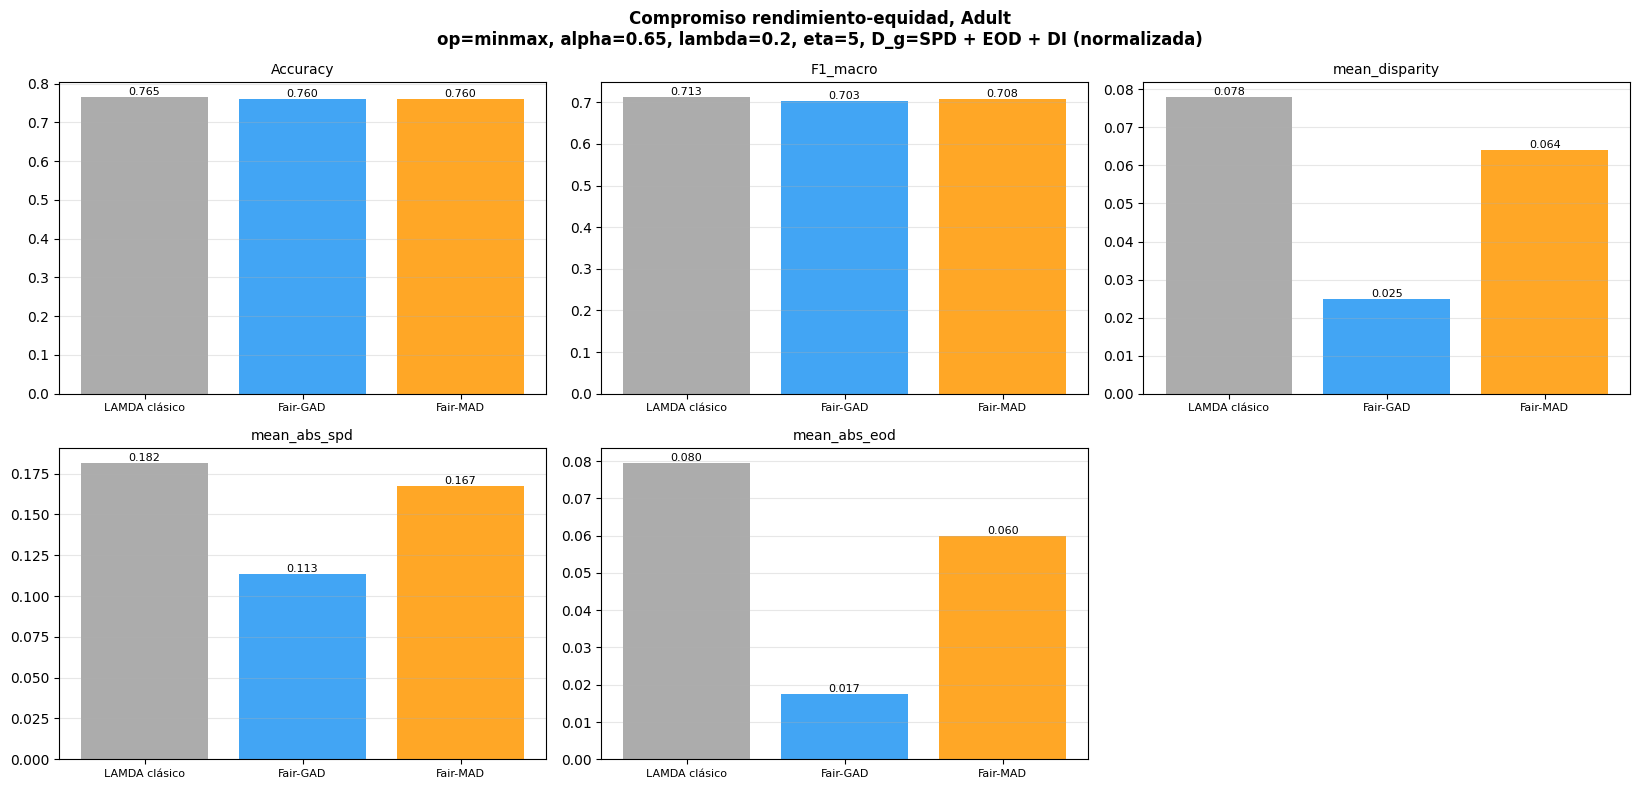

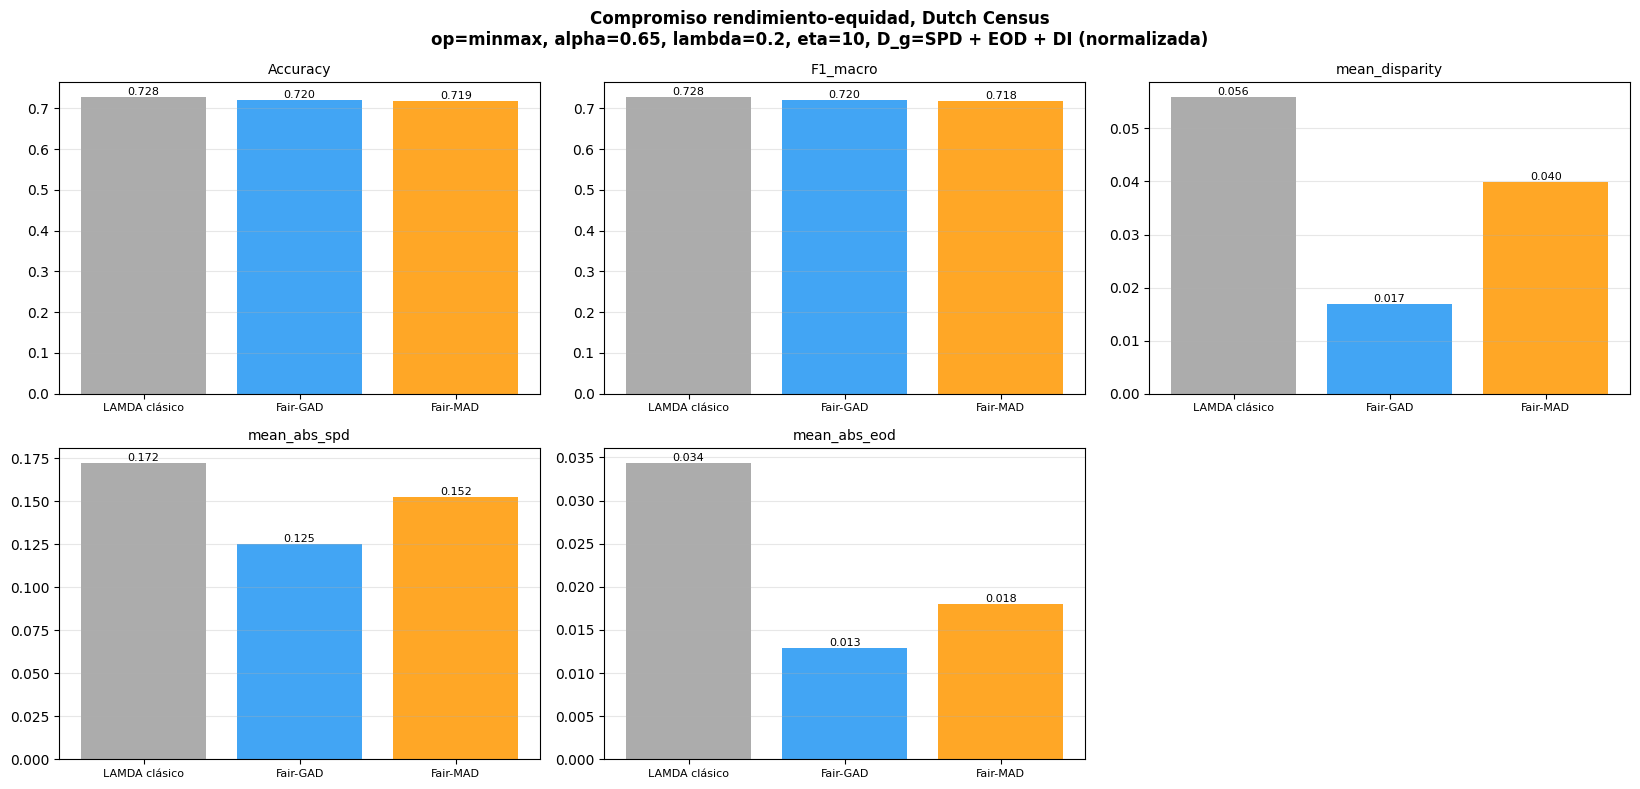

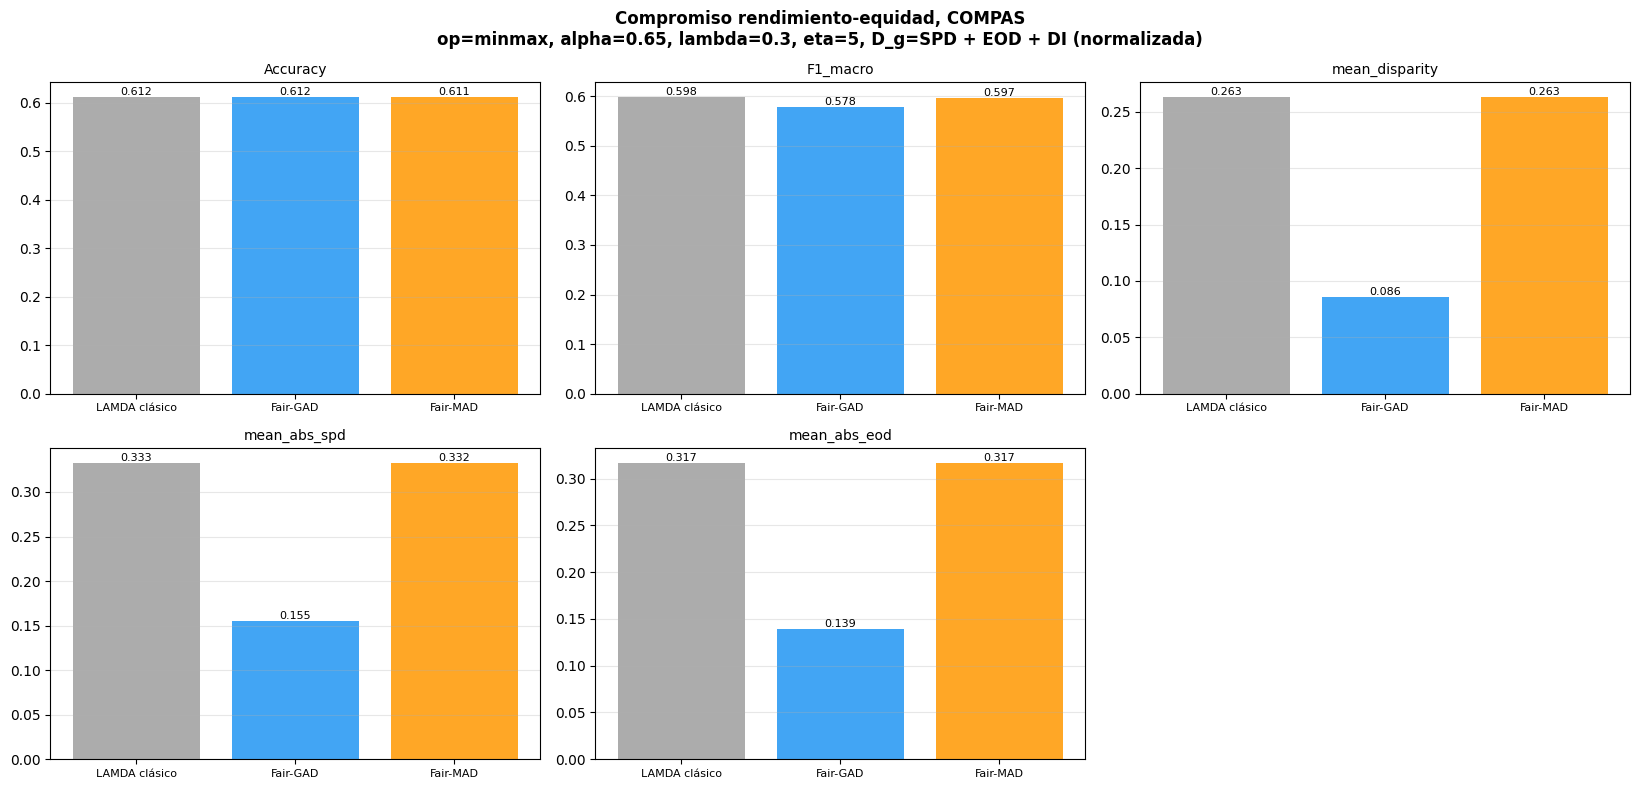

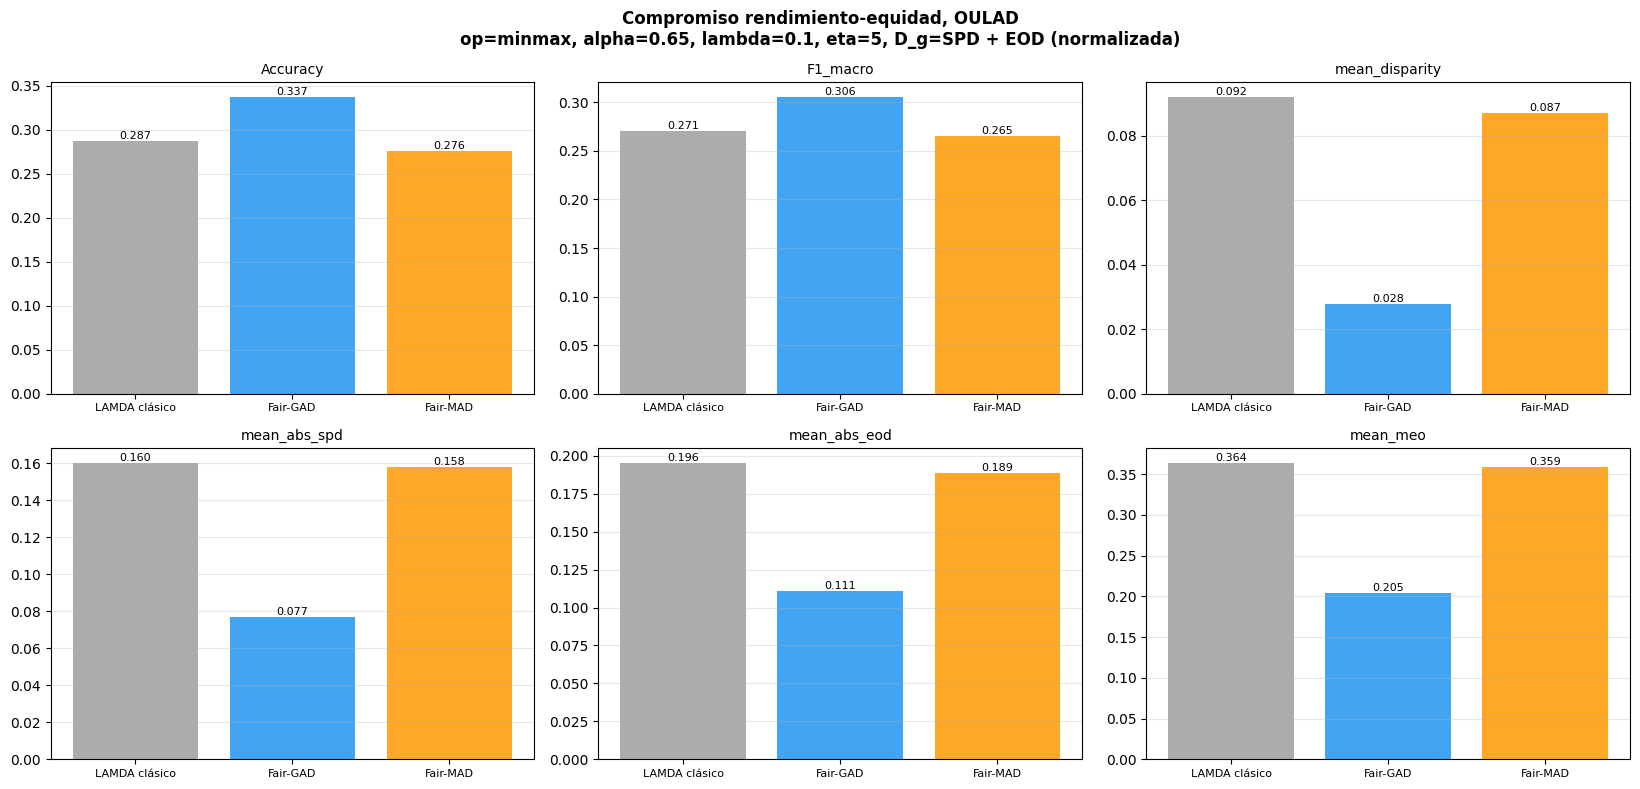

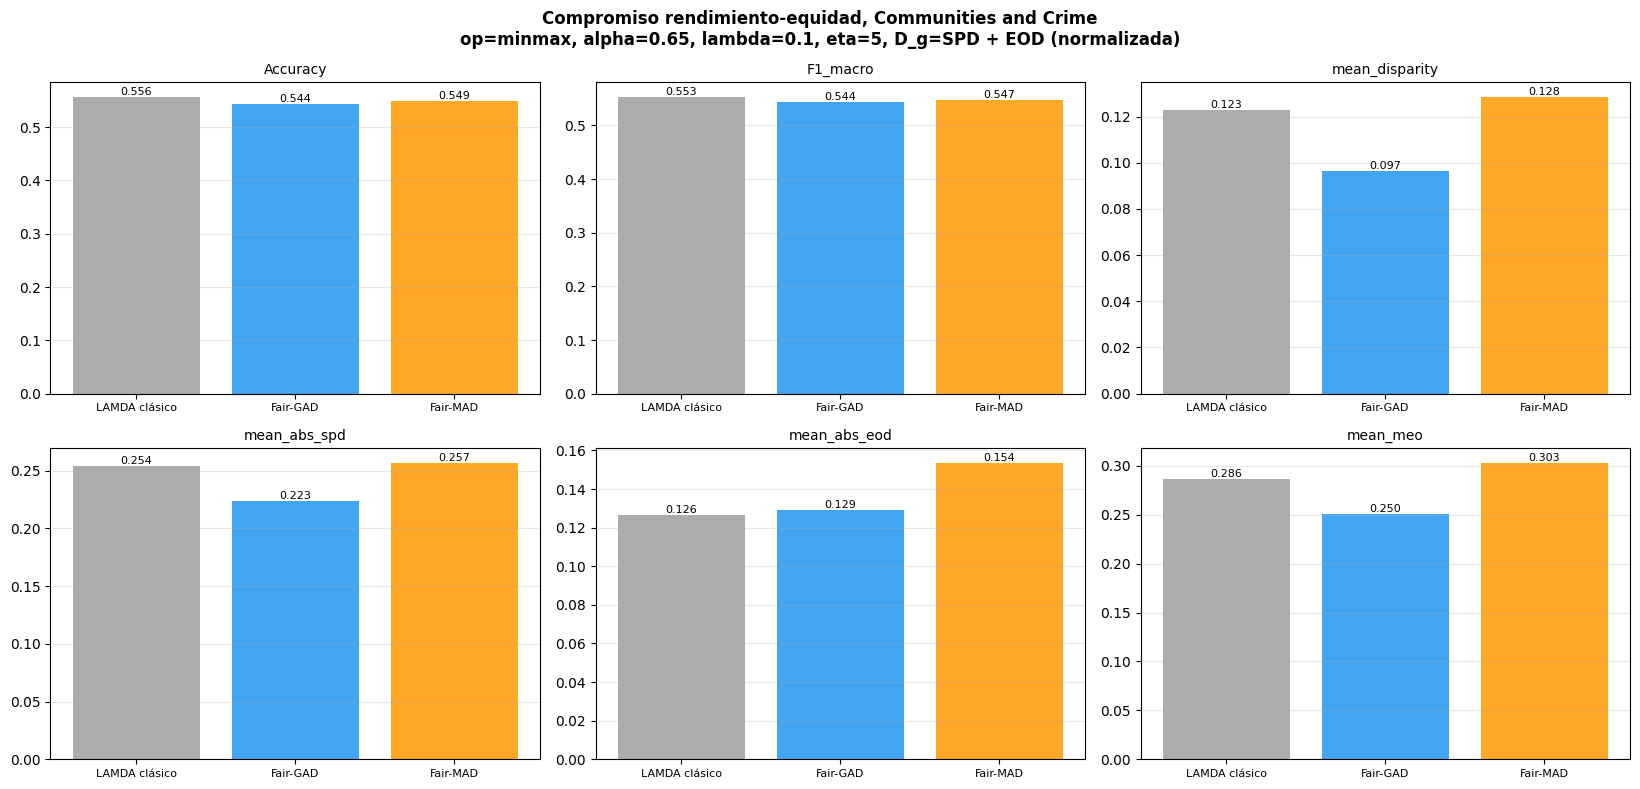

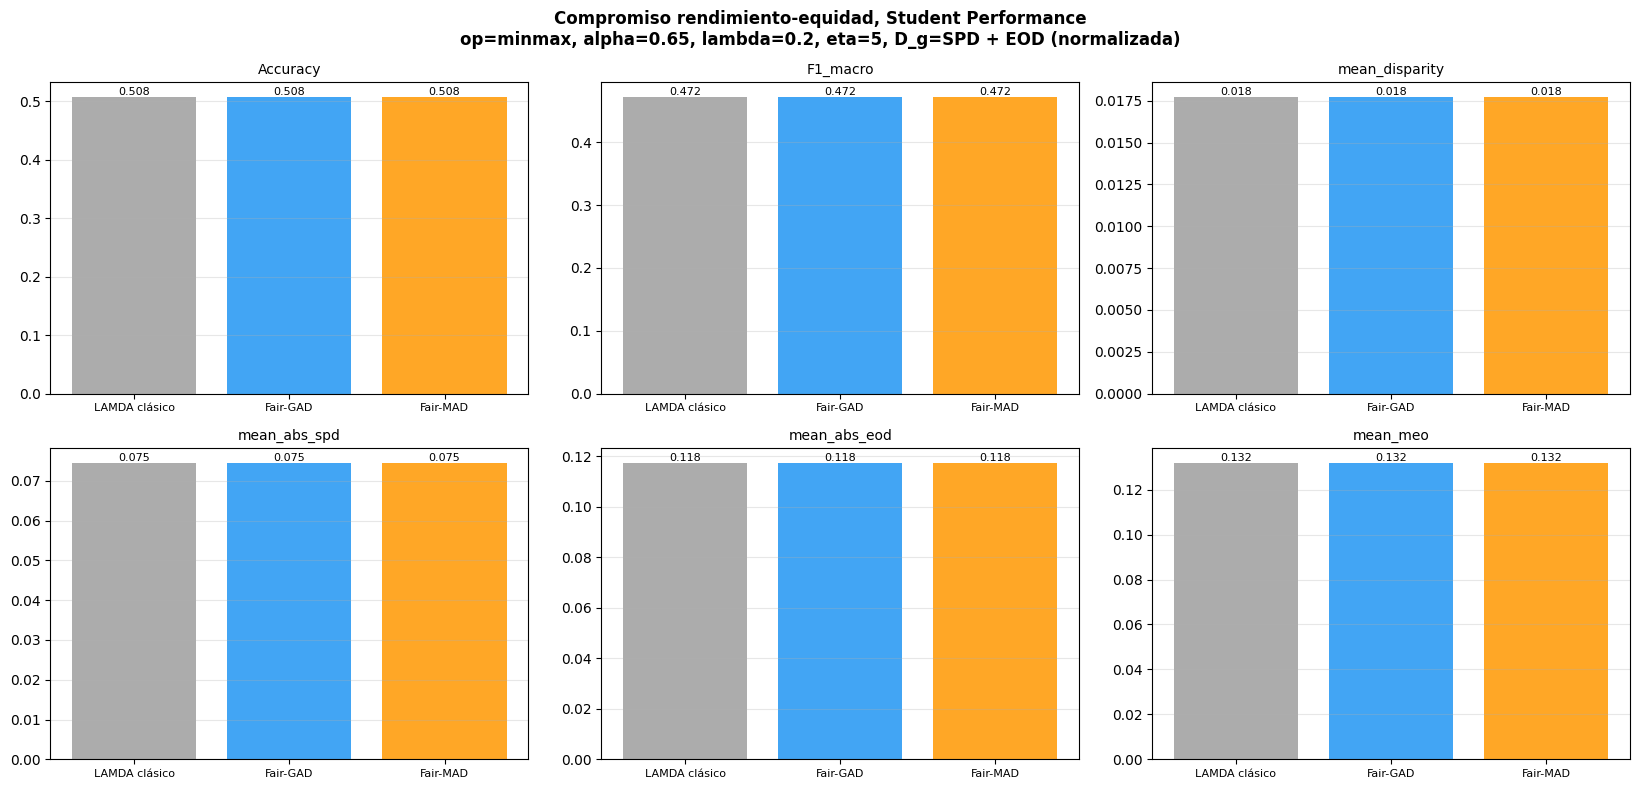

In [22]:
COLORES = ["#9E9E9E", "#2196F3", "#FF9800"]

def figura_compromiso(name, guardar=True, mostrar=True):
    """Figura de compromiso rendimiento-equidad de un conjunto."""
    tabla = mitigation_results[name].mitigation_table
    modelos = tabla.index.tolist()
    metricas = ["Accuracy", "F1_macro", "mean_disparity", "mean_abs_spd", "mean_abs_eod"]
    if "mean_meo" in tabla.columns and not tabla["mean_meo"].isna().all():
        metricas.append("mean_meo")
    ncols = 3
    nrows = int(np.ceil(len(metricas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
    axes = np.array(axes).flatten()
    x = np.arange(len(modelos))
    for ax, col in zip(axes, metricas):
        bars = ax.bar(x, tabla[col].to_numpy(dtype=float), color=COLORES, alpha=0.85)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)
        ax.set_title(col, fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=8)
        ax.grid(axis="y", alpha=0.3)
    for ax in axes[len(metricas):]:
        ax.axis("off")
    plt.suptitle(f"Compromiso rendimiento-equidad, {cfg.DATASETS[name].display_name}\n"
                 f"op={OPERATOR}, alpha={ALPHA}, lambda={lambda_de(name)}, eta={eta_de(name)}, "
                 f"D_g={descripcion_composicion(name)}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    if mostrar:
        plt.show()
    else:
        plt.close(fig)

for name in datasets_activos():
    figura_compromiso(name)


## Descriptores penalizados por Fair-MAD

Un peso próximo a cero indica neutralización casi completa del descriptor; un peso igual a uno indica que su impacto no supera el umbral y no se penaliza.

La primera salida resume, para los seis conjuntos, cuánto se separan los pesos de la unidad. Ese resumen es el criterio para decidir en qué casos se incluye la figura de descriptores, en lugar de fijarlo de antemano.

,Nº de descriptores,w mínimo,w medio,"Penalizados (w < 0,99)","Penalizados (w < 0,80)"
Dataset,,,,,
Adult,87,0.8753,0.9938,10,0
Dutch Census,50,0.8846,0.9854,13,0
COMPAS,14,0.8344,0.9821,2,0
OULAD,48,0.9124,0.9950,7,0
Communities and Crime,122,0.9582,0.9979,7,0
Student Performance,56,0.9883,0.9987,4,0


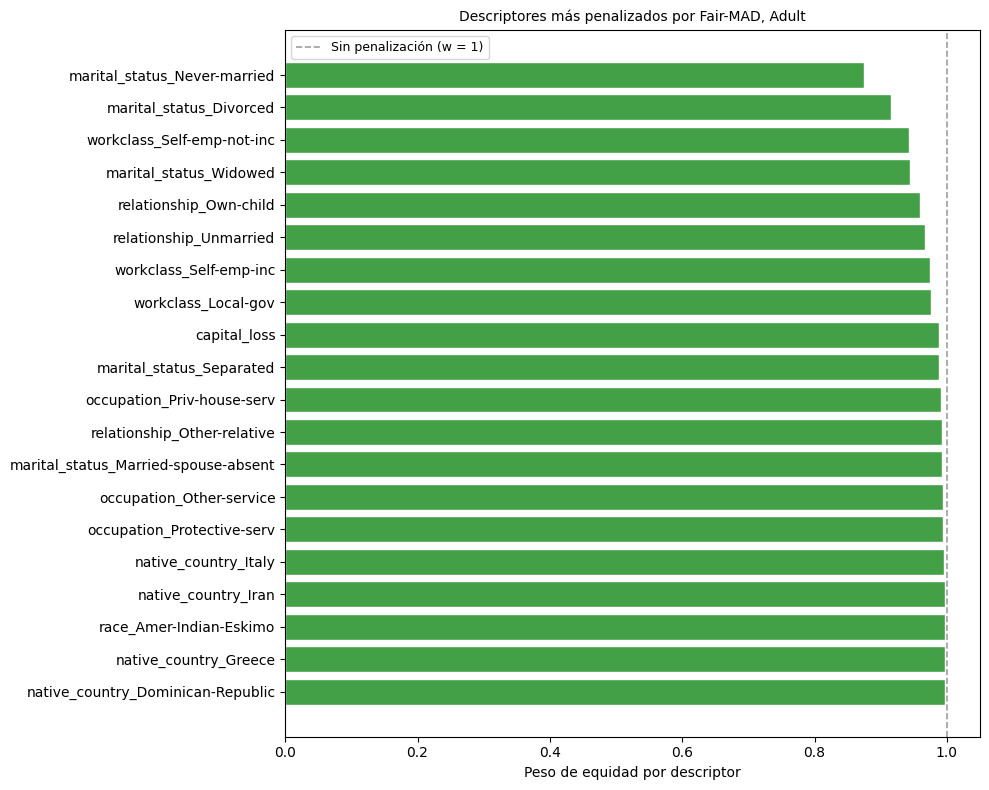

,feature,w_j,D_j
16,marital_status_Never-married,0.8753,0.0285
12,marital_status_Divorced,0.9153,0.0185
9,workclass_Self-emp-not-inc,0.9432,0.0120
18,marital_status_Widowed,0.9448,0.0117
36,relationship_Own-child,0.9589,0.0086
37,relationship_Unmarried,0.9663,0.0070
8,workclass_Self-emp-inc,0.9748,0.0052
6,workclass_Local-gov,0.9764,0.0048
3,capital_loss,0.9881,0.0024
17,marital_status_Separated,0.9883,0.0024


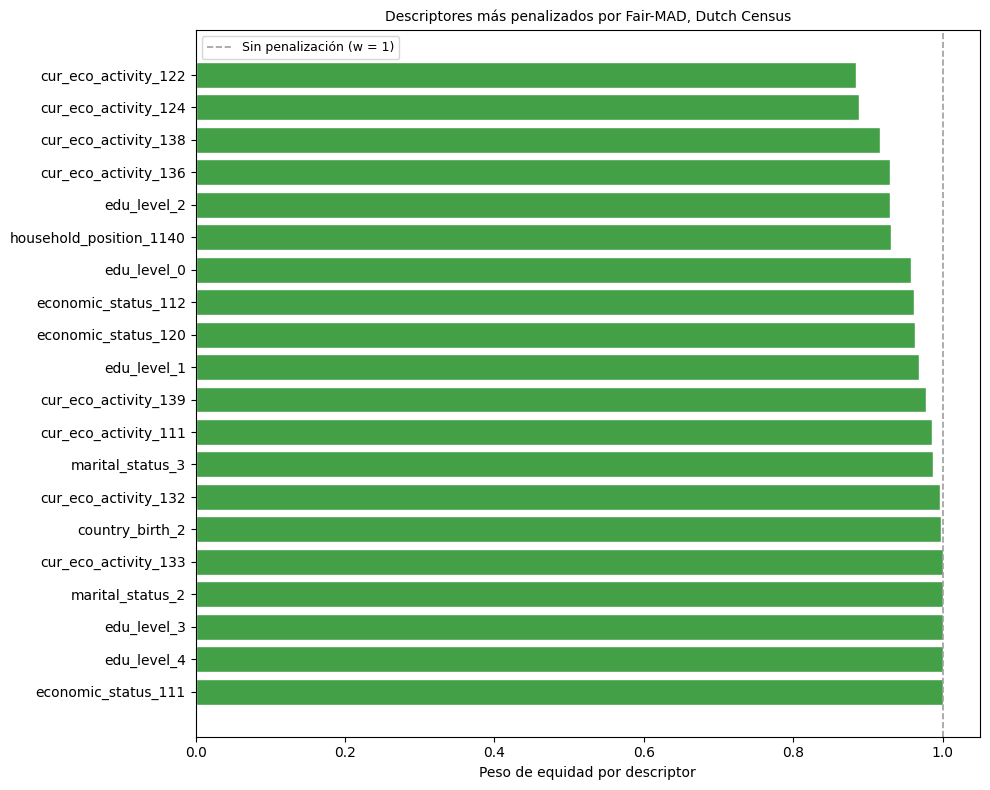

,feature,w_j,D_j
35,cur_eco_activity_122,0.8846,0.0131
36,cur_eco_activity_124,0.8878,0.0126
44,cur_eco_activity_138,0.9165,0.0091
42,cur_eco_activity_136,0.9289,0.0076
27,edu_level_2,0.9289,0.0076
8,household_position_1140,0.9308,0.0074
25,edu_level_0,0.9573,0.0045
32,economic_status_112,0.9620,0.0039
33,economic_status_120,0.9626,0.0039
26,edu_level_1,0.9682,0.0033


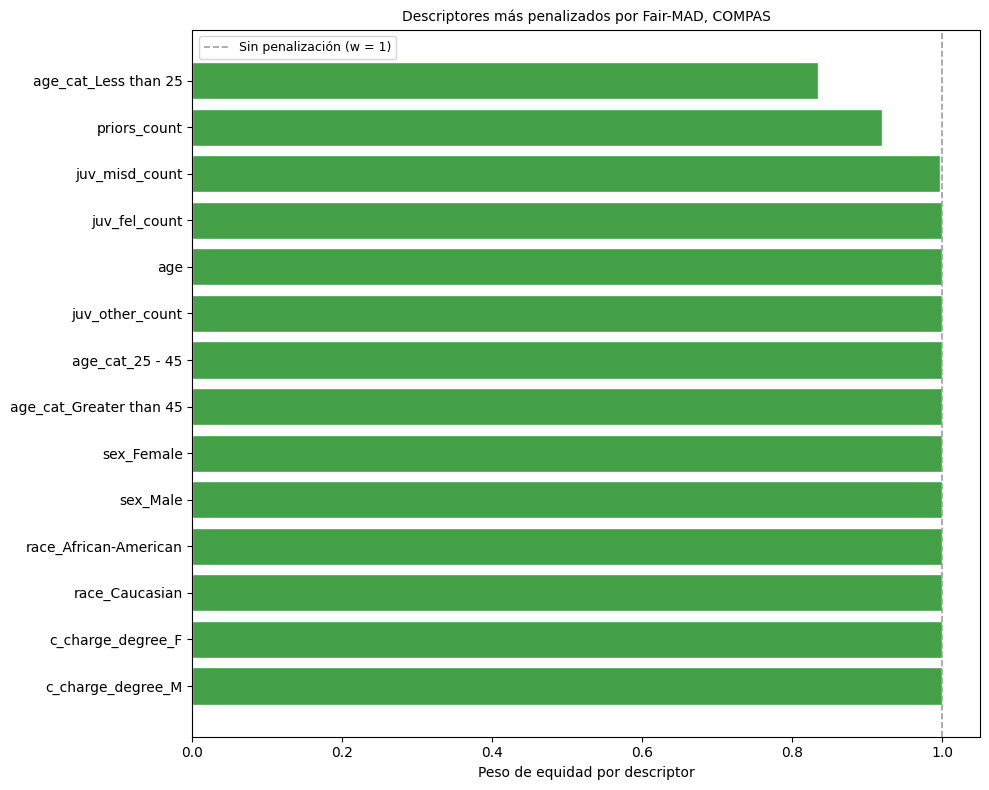

,feature,w_j,D_j
7,age_cat_Less than 25,0.8344,0.0397
4,priors_count,0.9187,0.0177
2,juv_misd_count,0.9961,0.0008
1,juv_fel_count,0.9999,0.0000
0,age,1.0000,0.0000
3,juv_other_count,1.0000,0.0000
5,age_cat_25 - 45,1.0000,0.0000
6,age_cat_Greater than 45,1.0000,0.0000
8,sex_Female,1.0000,0.0000
9,sex_Male,1.0000,0.0000


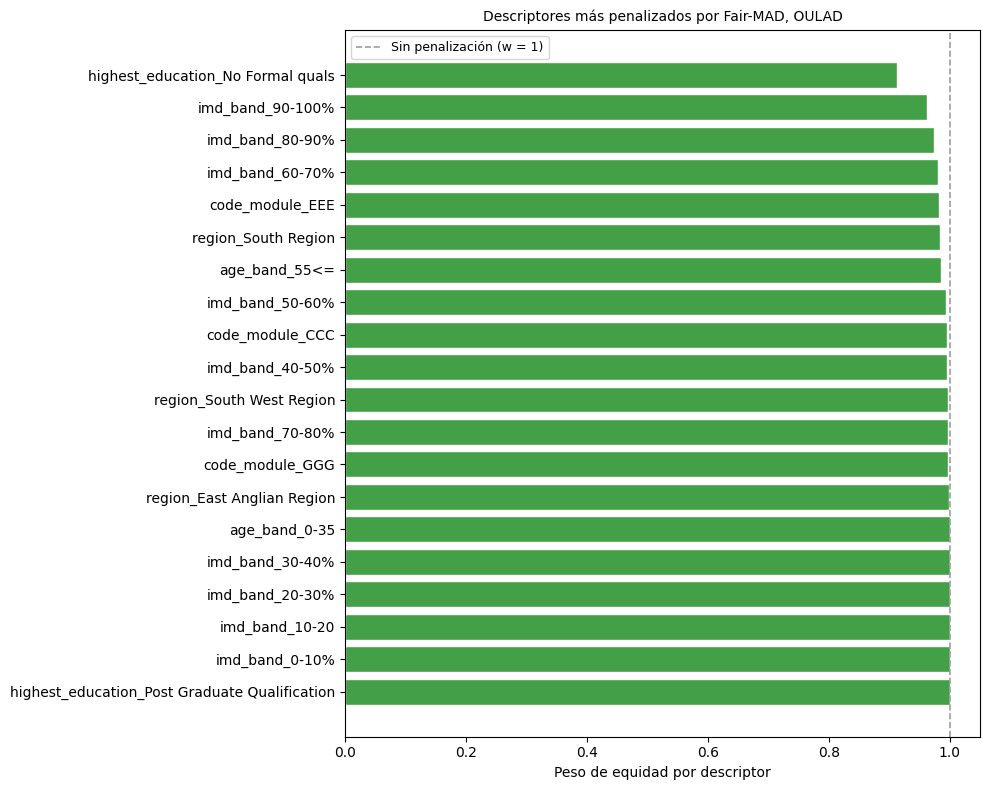

,feature,w_j,D_j
31,highest_education_No Formal quals,0.9124,0.0192
42,imd_band_90-100%,0.9623,0.0078
41,imd_band_80-90%,0.9736,0.0054
39,imd_band_60-70%,0.9802,0.0040
6,code_module_EEE,0.9828,0.0035
23,region_South Region,0.9840,0.0033
45,age_band_55<=,0.9849,0.0031
38,imd_band_50-60%,0.9945,0.0011
4,code_module_CCC,0.9962,0.0008
37,imd_band_40-50%,0.9962,0.0008


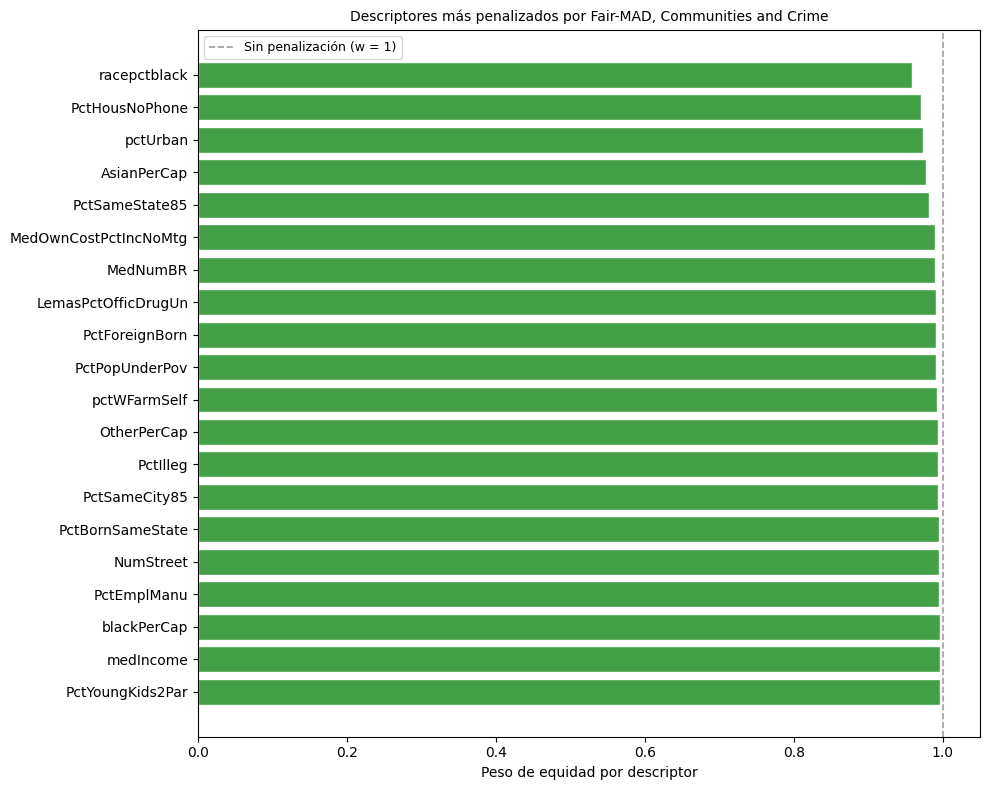

,feature,w_j,D_j
2,racepctblack,0.9582,0.0087
77,PctHousNoPhone,0.9706,0.0061
11,pctUrban,0.9737,0.0054
24,AsianPerCap,0.9781,0.0045
95,PctSameState85,0.9817,0.0037
88,MedOwnCostPctIncNoMtg,0.9896,0.0021
70,MedNumBR,0.9897,0.0021
120,LemasPctOfficDrugUn,0.9905,0.0019
91,PctForeignBorn,0.9907,0.0019
28,PctPopUnderPov,0.9908,0.0019


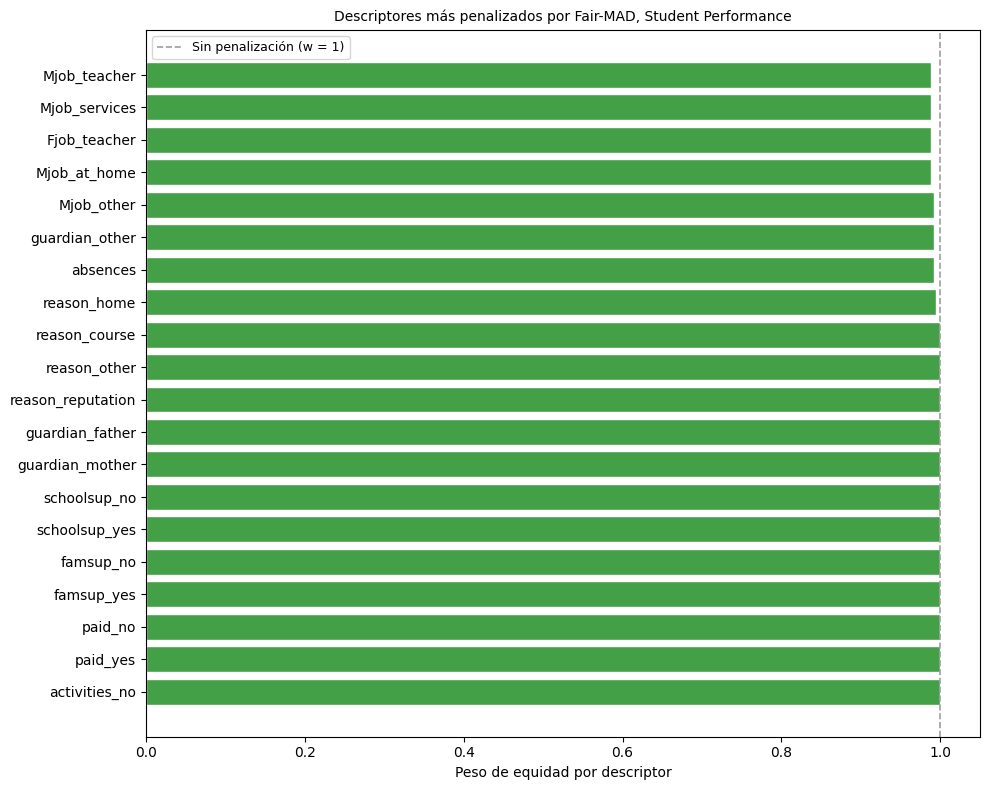

,feature,w_j,D_j
27,Mjob_teacher,0.9883,0.0024
26,Mjob_services,0.9883,0.0024
32,Fjob_teacher,0.9883,0.0024
23,Mjob_at_home,0.9883,0.0024
25,Mjob_other,0.9923,0.0015
39,guardian_other,0.9923,0.0015
12,absences,0.9923,0.0015
34,reason_home,0.9946,0.0011
33,reason_course,1.0000,0.0000
35,reason_other,1.0000,0.0000


In [23]:
UMBRAL_SEPARACION = 0.99   # por debajo de este peso se considera penalización apreciable
TOP_N = 20

filas_desc = []
for name in datasets_activos():
    dw = mitigation_results[name].descriptor_weights
    w = dw["w_j"].to_numpy(dtype=float)
    filas_desc.append({
        "Dataset": cfg.DATASETS[name].display_name,
        "Nº de descriptores": len(w),
        "w mínimo": w.min(),
        "w medio": w.mean(),
        "Penalizados (w < 0,99)": int((w < UMBRAL_SEPARACION).sum()),
        "Penalizados (w < 0,80)": int((w < 0.80).sum()),
    })
resumen_descriptores = pd.DataFrame(filas_desc).set_index("Dataset")
resumen_descriptores.to_csv(os.path.join(cfg.RESULTS_DIR, "resumen_descriptores.csv"))
display(resumen_descriptores)

def figura_descriptores(name, top_n=TOP_N, guardar=True, mostrar=True):
    """Descriptores más penalizados por Fair-MAD en un conjunto."""
    top_df = mitigation_results[name].descriptor_weights.head(top_n).copy()
    fig, ax = plt.subplots(figsize=(10, max(5, top_n*0.4)))
    colores = ["#E53935" if w < 0.5 else "#FF9800" if w < 0.8 else "#43A047"
               for w in top_df["w_j"]]
    ax.barh(top_df["feature"].astype(str), top_df["w_j"], color=colores, edgecolor="white")
    ax.axvline(x=1.0, color="#9E9E9E", linestyle="--", linewidth=1.2,
               label="Sin penalización (w = 1)")
    ax.set_xlabel("Peso de equidad por descriptor")
    ax.set_xlim(0, 1.05); ax.invert_yaxis(); ax.legend(fontsize=9)
    ax.set_title(f"Descriptores más penalizados por Fair-MAD, "
                 f"{cfg.DATASETS[name].display_name}", fontsize=10)
    plt.tight_layout()
    if mostrar:
        plt.show()
    else:
        plt.close(fig)
    return top_df

# Se genera la figura y la tabla en todos los conjuntos con penalización
# apreciable; el resto solo se documenta en el resumen anterior.
tablas_descriptores = {}
for name in datasets_activos():
    if float(mitigation_results[name].descriptor_weights["w_j"].min()) < UMBRAL_SEPARACION:
        tablas_descriptores[name] = figura_descriptores(name)
        display(tablas_descriptores[name])
    else:
        print(f"[{name}] sin penalización apreciable: todos los pesos en la unidad.")


## Matrices de confusión de los tres modelos (diagnóstico)

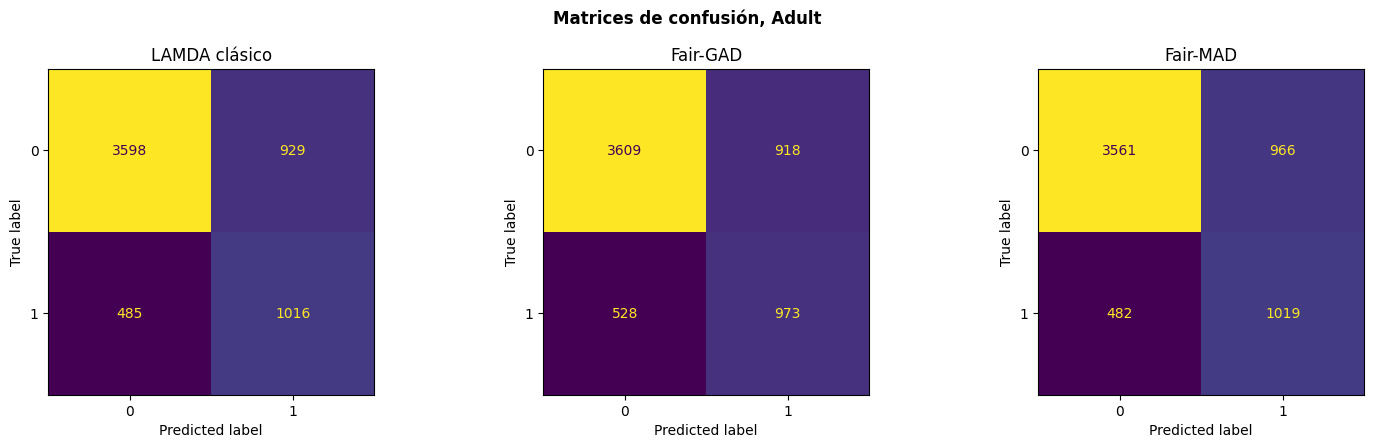

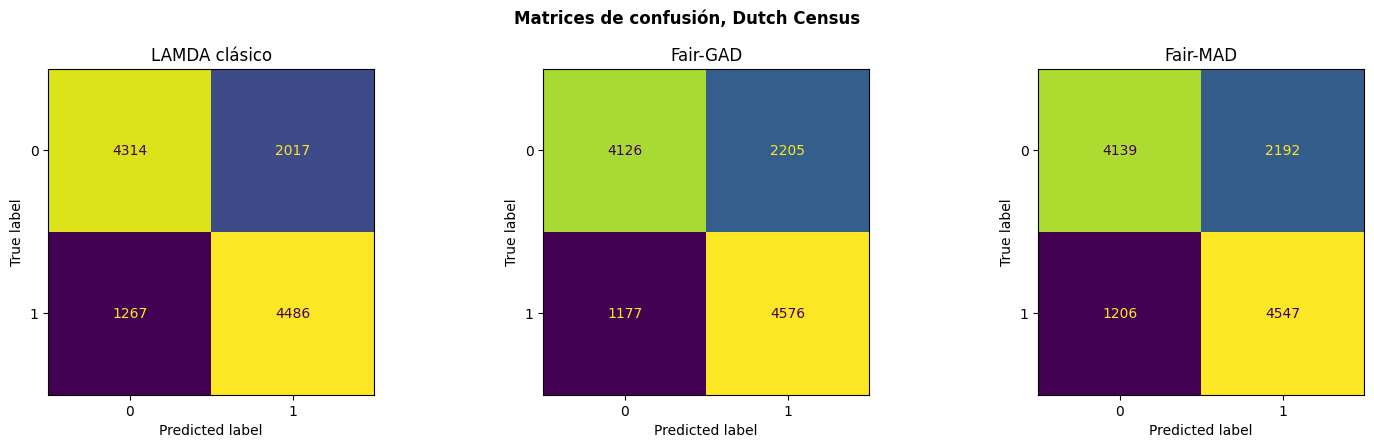

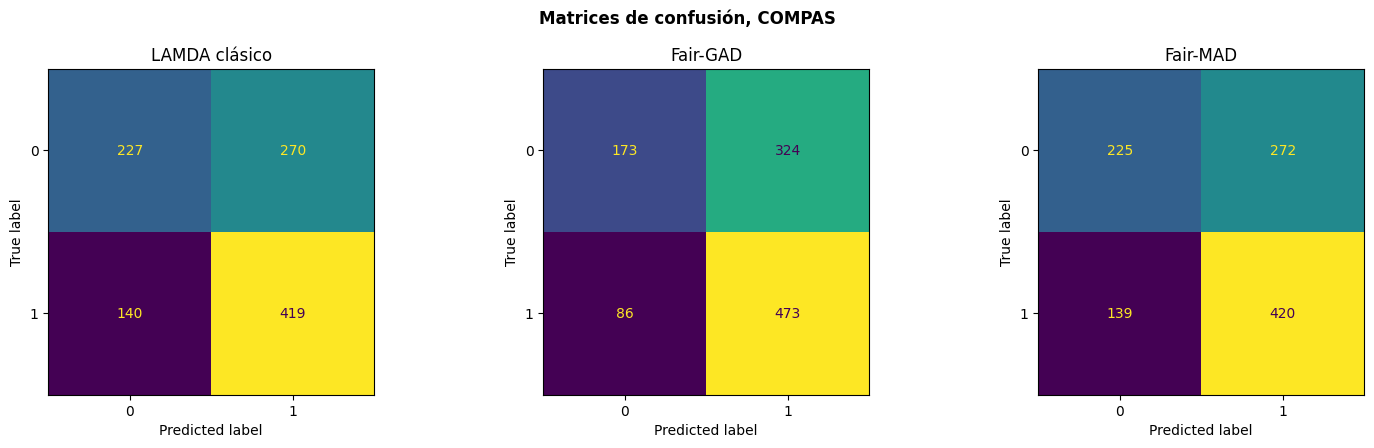

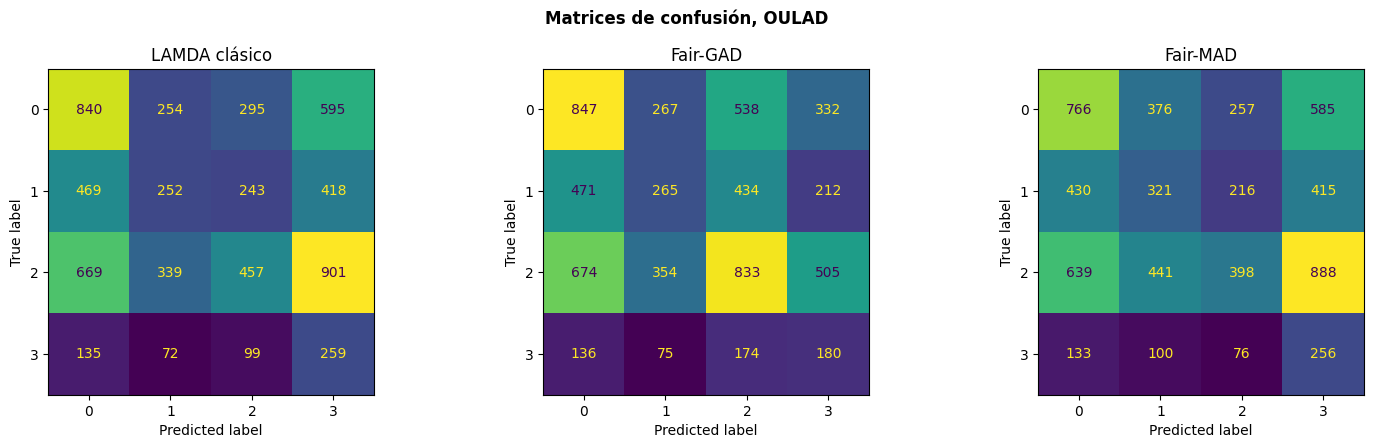

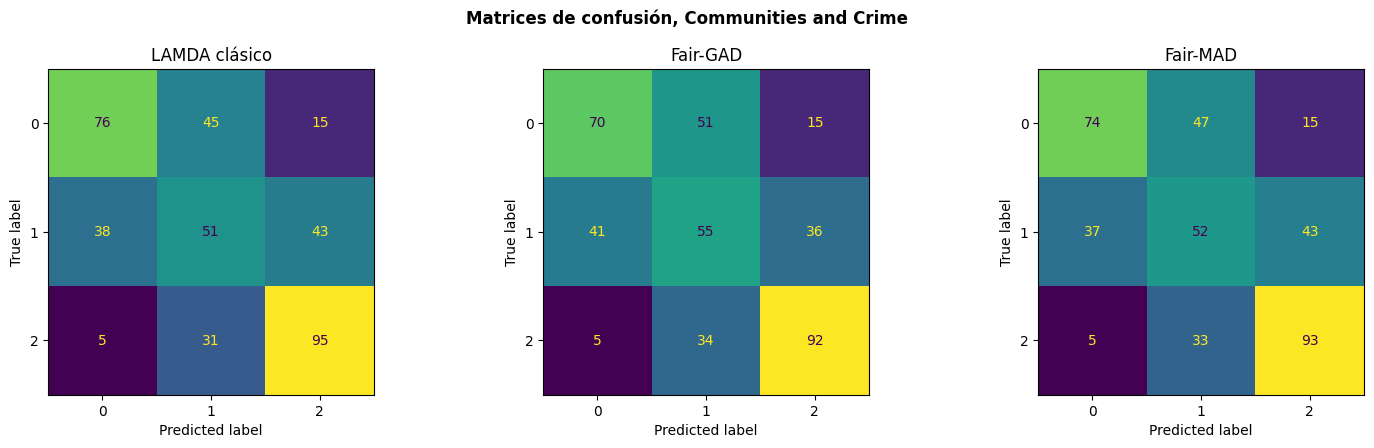

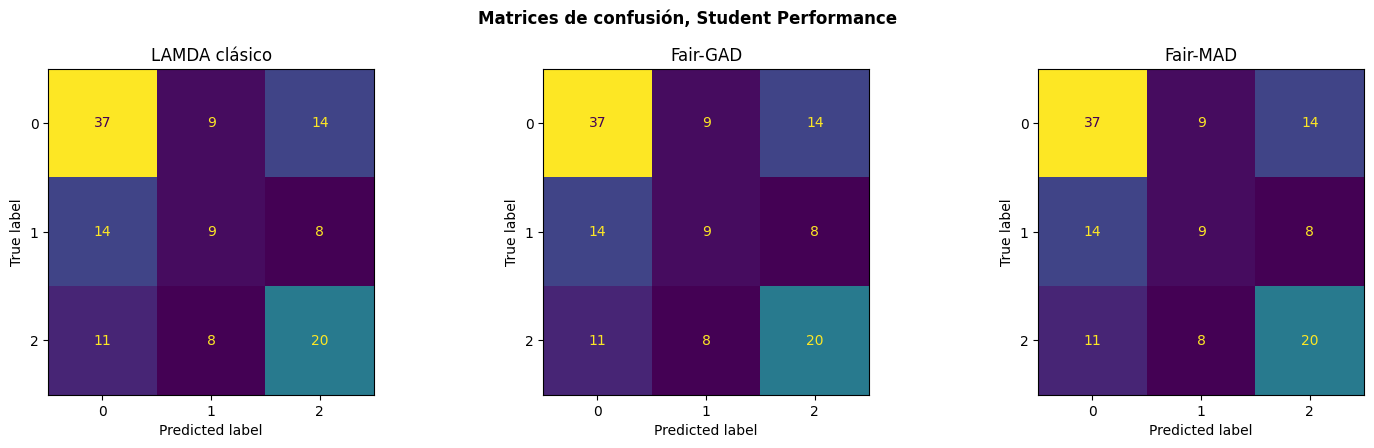

In [24]:
for name in datasets_activos():
    res = mitigation_results[name]
    y_test = res.predictions["y_test"]
    etiquetas = [("LAMDA clásico", "classic"), ("Fair-GAD", "fair_gad"),
                 ("Fair-GAD dirigido", "fair_gad_dir"),
                 ("Fair-MAD", "fair_mad"),
                 ("Fair-MAD dirigido", "fair_mad_dir")]
    preds = [(t, res.predictions[k]) for t, k in etiquetas
             if res.predictions.get(k) is not None]
    fig, axes = plt.subplots(1, len(preds), figsize=(5*len(preds), 4.5))
    axes = np.atleast_1d(axes)
    for ax, (etiqueta, yp) in zip(axes, preds):
        ConfusionMatrixDisplay(
            confusion_matrix=confusion_matrix(y_test, yp)).plot(ax=ax, colorbar=False)
        ax.set_title(etiqueta)
    plt.suptitle(f"Matrices de confusión, {cfg.DATASETS[name].display_name}",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()


Diagnóstico de convergencia sobre **entrenamiento**, no resultado de generalización. Explica cómo se alcanzaron los valores finales de la disparidad y de los pesos por descriptor.

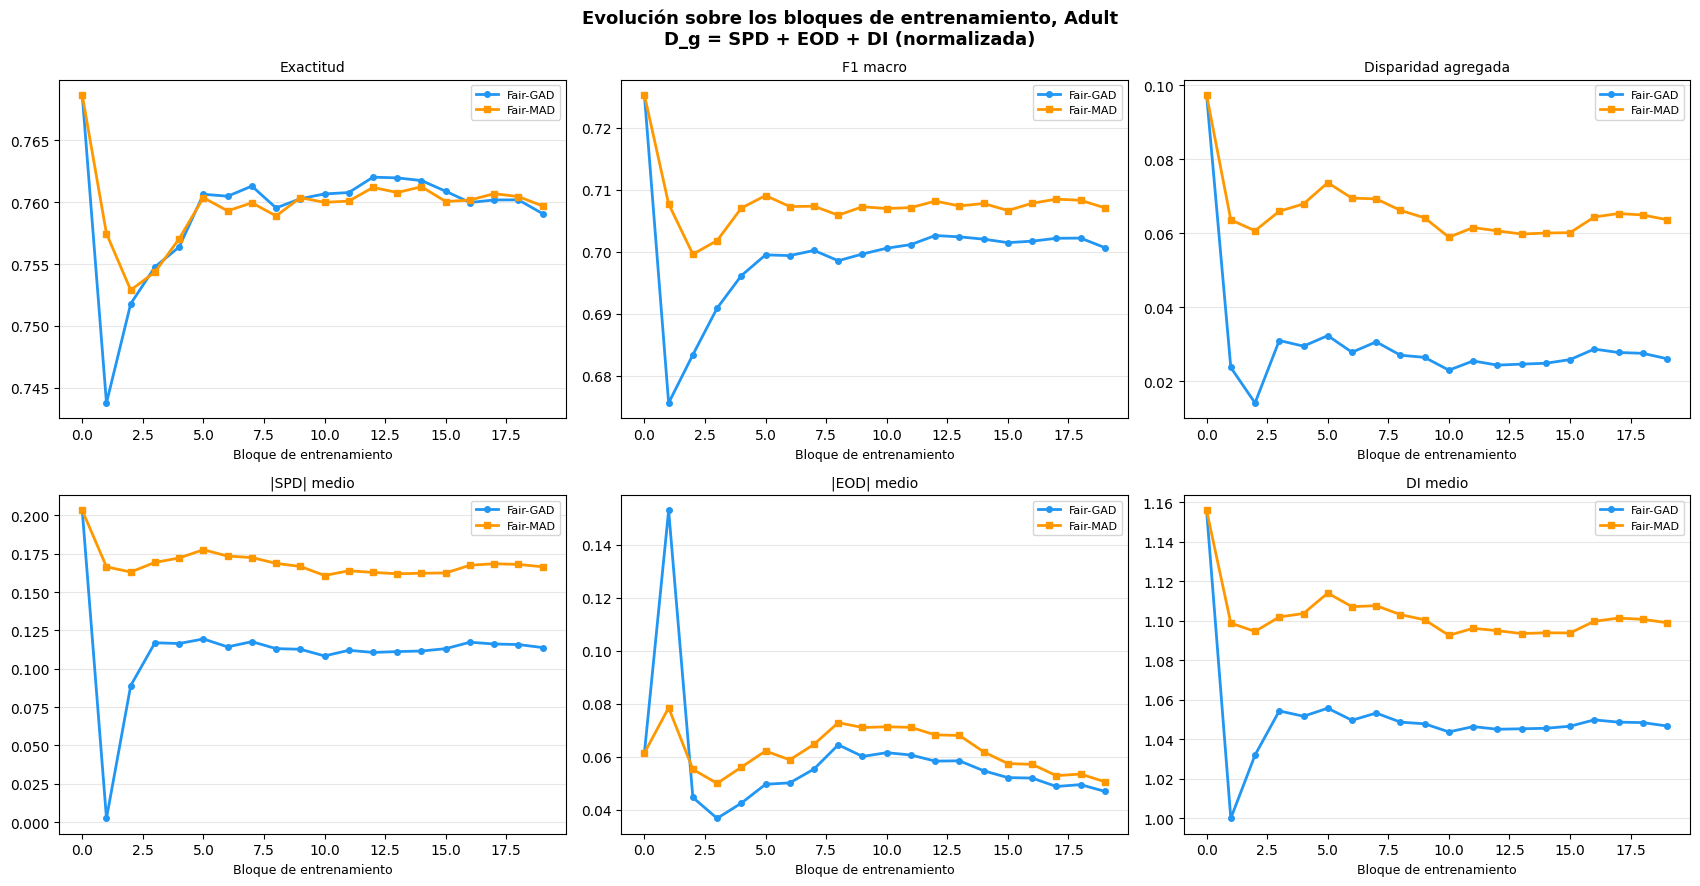

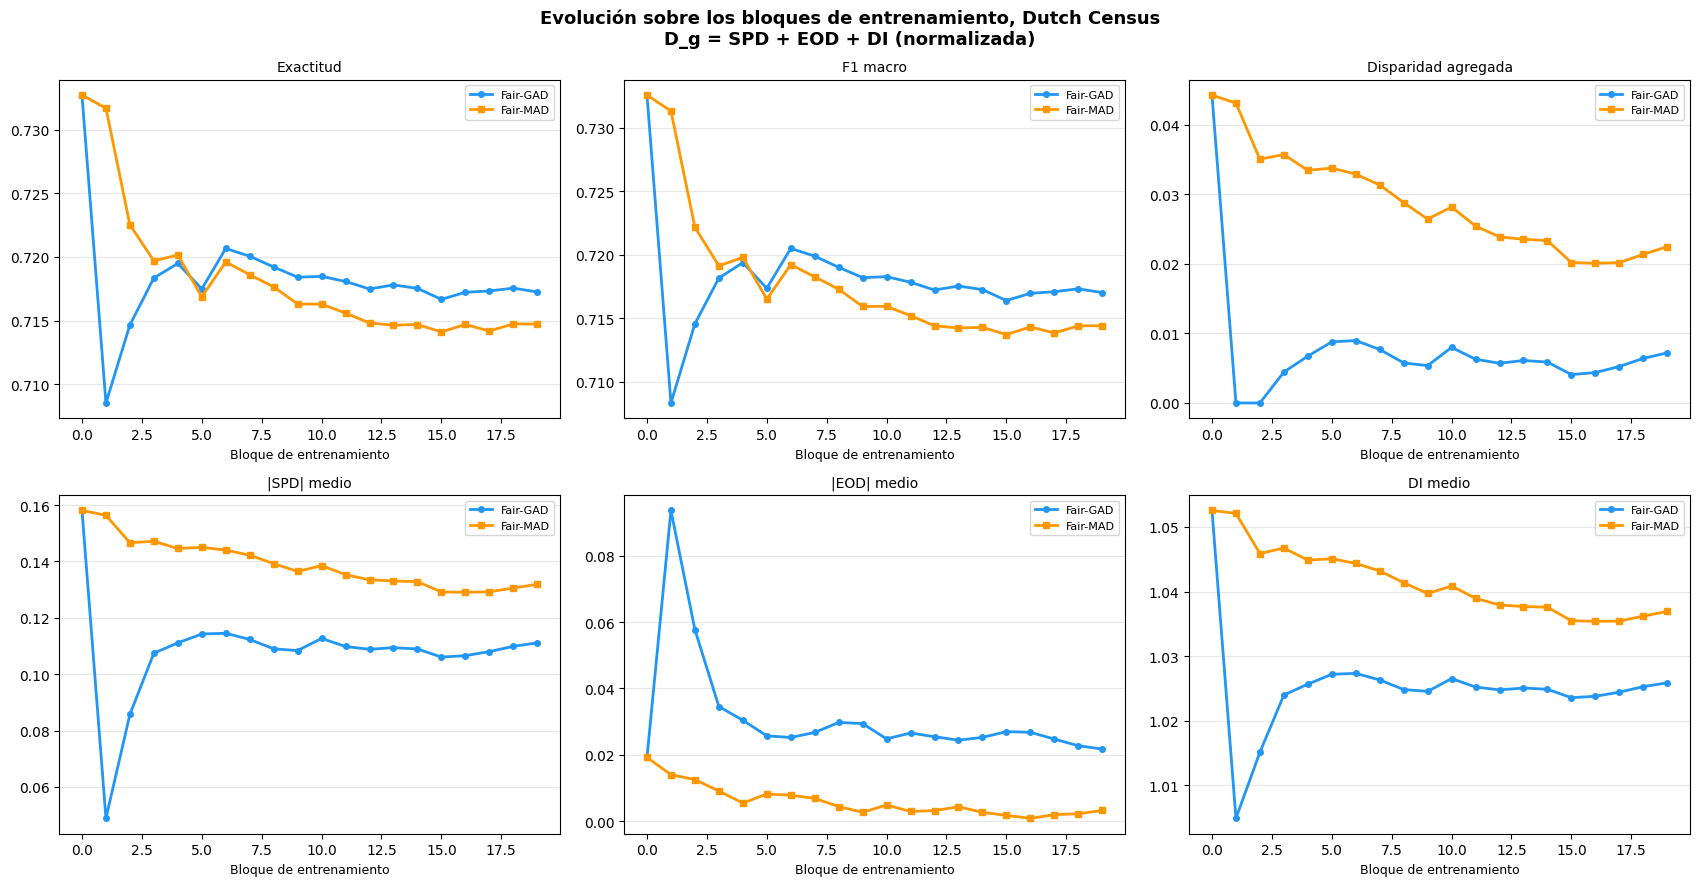

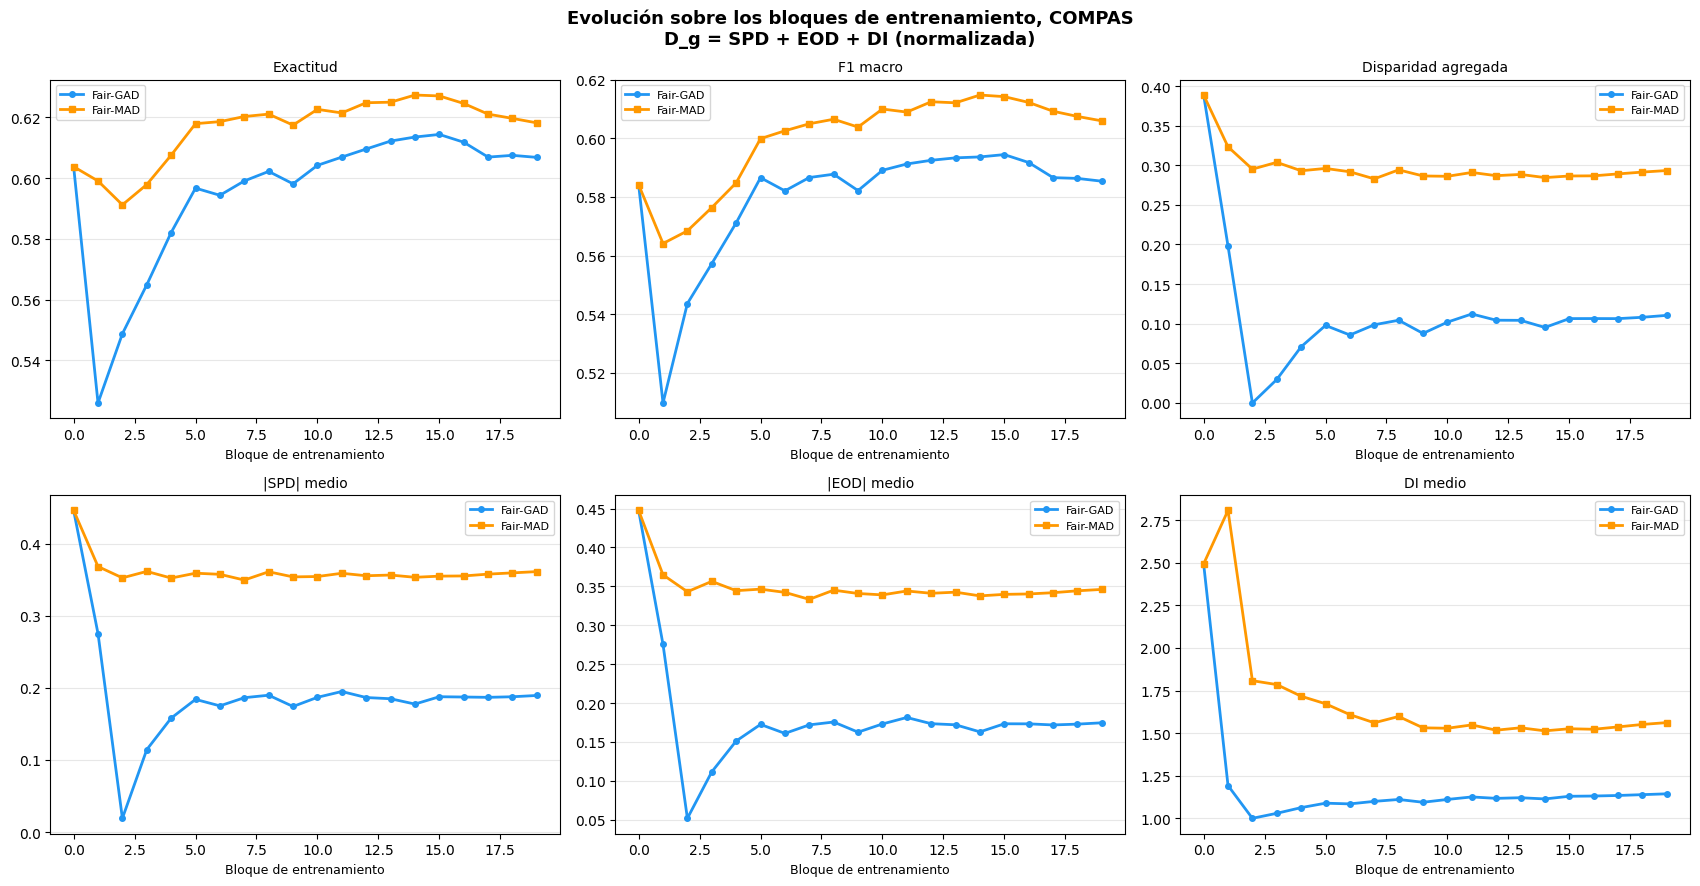

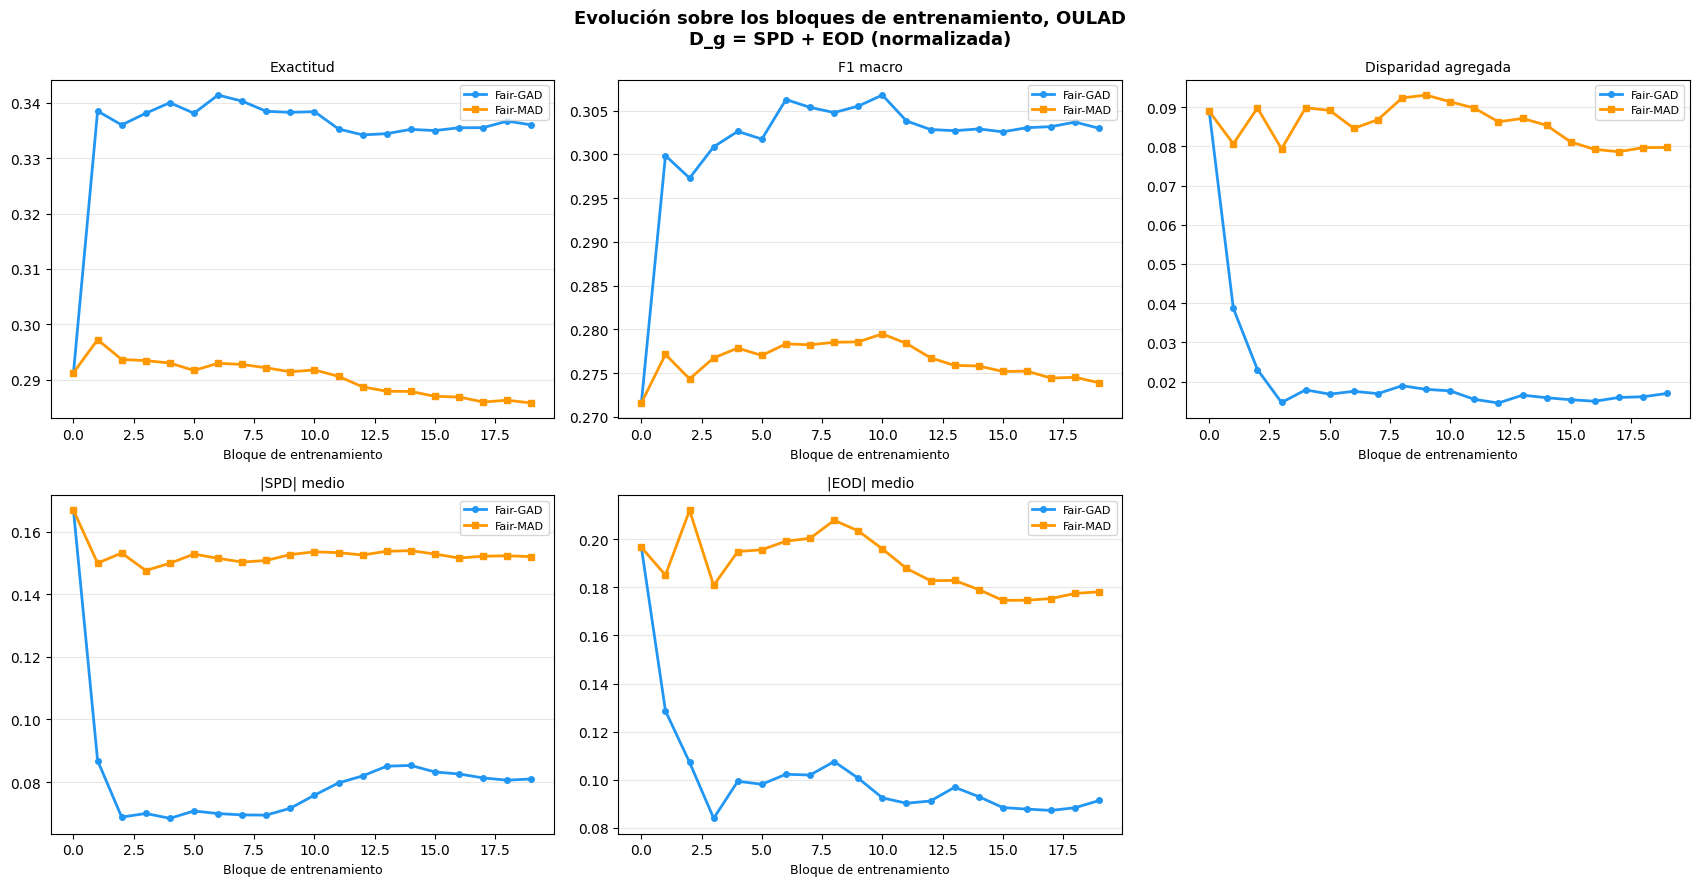

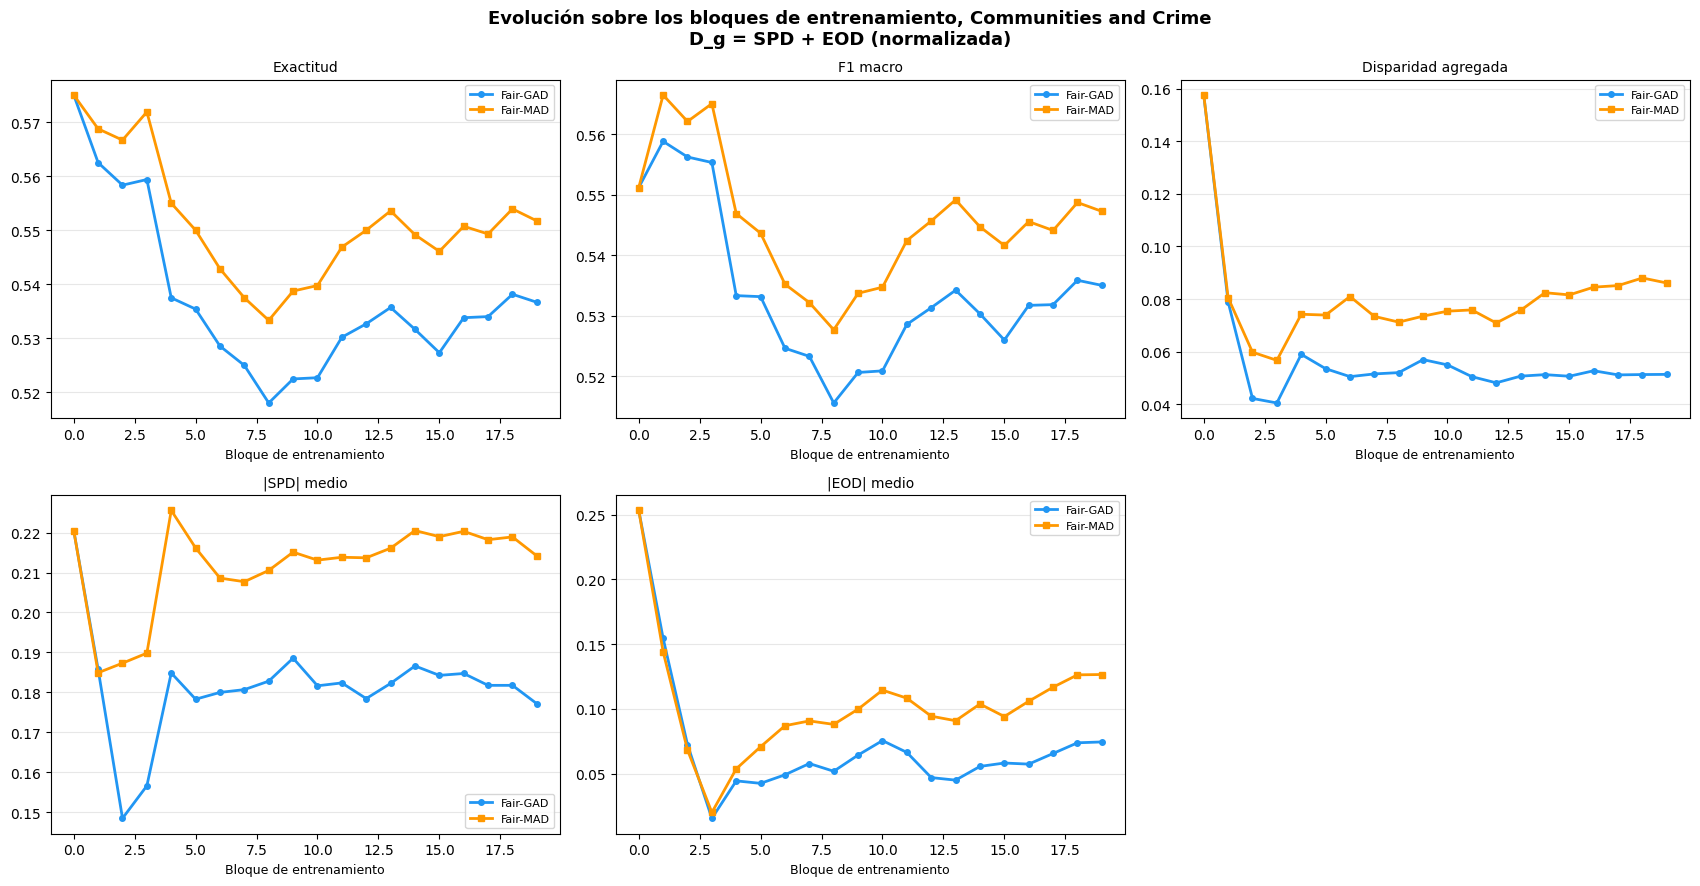

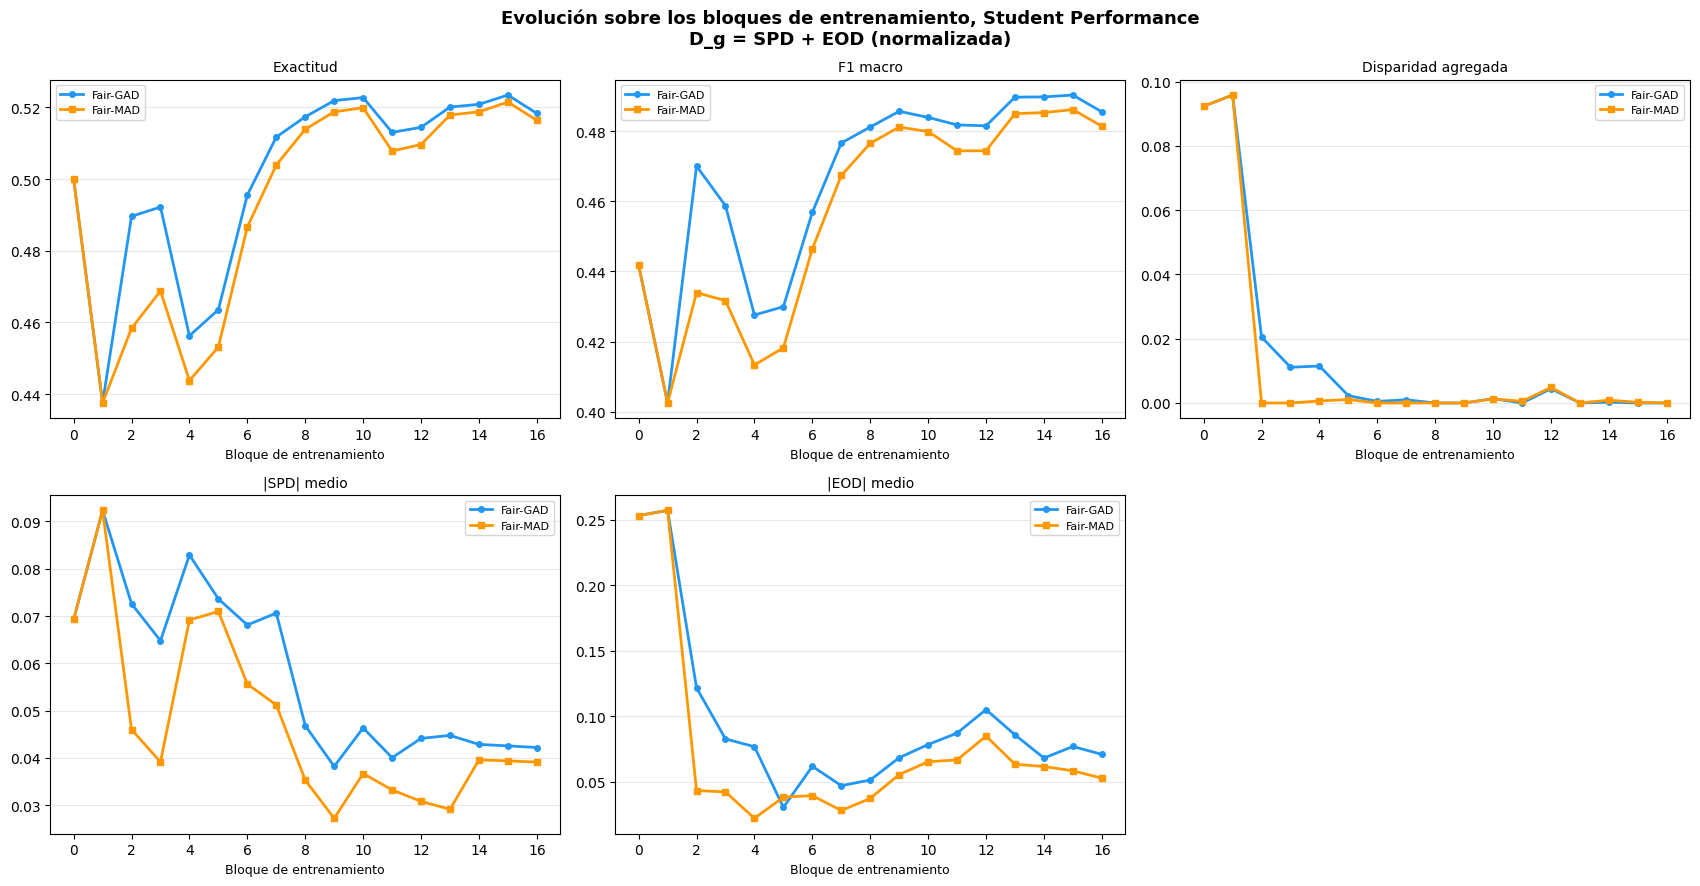

Nº de bloques  D_g en el primer bloque  D_g en el último bloque  Bloque de estabilización  Rango de la señal
Dataset               Modelo                                                                                                                
Adult                 Fair-GAD             20                   0.0973                   0.0261                        12             0.0832
                      Fair-MAD             20                   0.0973                   0.0637                         7             0.0384
Dutch Census          Fair-GAD             20                   0.0442                   0.0072                        20             0.0442
                      Fair-MAD             20                   0.0442                   0.0225                        19             0.0242
COMPAS                Fair-GAD             20                   0.3886                   0.1106                        16             0.3886
                      Fair-MAD             20                   0.3886                   0.2933                         3             0.1058
OULAD                 Fair-GAD             20                   0.0889                   0.0170                        18             0.0744
                      Fair-MAD             20                   0.0889                   0.0797                        13             0.0145
Communities and Crime Fair-GAD             20                   0.1576                   0.0514                        11             0.1170
                      Fair-MAD             20                   0.1576                   0.0861                        15             0.1008
Student Performance   Fair-GAD             17                   0.0923                   0.0000                        16             0.0958
                      Fair-MAD             17                   0.0923                   0.0000                        17             0.0958

In [25]:
# =========================================================
# EVOLUCIÓN DURANTE EL ENTRENAMIENTO
# =========================================================
# Las curvas se calculan sobre los bloques de ENTRENAMIENTO del recorrido
# incremental, no sobre la partición de evaluación.

METRICAS_BASE = [("accuracy", "Exactitud"), ("f1_macro", "F1 macro"),
                 ("mean_disparity", "Disparidad agregada"),
                 ("mean_abs_spd", "|SPD| medio"), ("mean_abs_eod", "|EOD| medio")]
METRICA_DI = ("mean_di", "DI medio")


def metricas_evolucion(dataset):
    """Métricas representables en un conjunto, según su composición de D_g."""
    metricas = list(METRICAS_BASE)
    if pesos_de(dataset).di > 0:
        metricas.append(METRICA_DI)
    return metricas


for name in datasets_activos():
    res = mitigation_results[name]
    metricas = metricas_evolucion(name)
    series = [("Fair-GAD", res.evolution_gad, "#2196F3", "o"),
              ("Fair-MAD", res.evolution_mad, "#FF9800", "s")]

    ncols = 3
    nrows = int(np.ceil(len(metricas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.7 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()

    for ax, (col, label) in zip(axes, metricas):
        for etiqueta, ev, color, marca in series:
            if ev is not None and col in ev.columns:
                ax.plot(ev.index, ev[col], color=color, marker=marca,
                        markersize=4, linewidth=2, label=etiqueta)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Bloque de entrenamiento", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)
    for ax in axes[len(metricas):]:
        ax.axis("off")

    plt.suptitle(f"Evolución sobre los bloques de entrenamiento, "
                 f"{cfg.DATASETS[name].display_name}\n"
                 f"D_g = {descripcion_composicion(name)}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

filas_conv = []
for name in datasets_activos():
    res = mitigation_results[name]
    for etiqueta, ev in (("Fair-GAD", res.evolution_gad),
                         ("Fair-MAD", res.evolution_mad)):
        if ev is None or "mean_disparity" not in ev.columns:
            continue
        s = ev["mean_disparity"].to_numpy(dtype=float)
        final = s[-1]
        # Primer bloque a partir del cual la señal se mantiene dentro de una
        # banda del 10 % de su valor final hasta el final del recorrido.
        banda = 0.1 * abs(final) if abs(final) > 1e-12 else 1e-12
        estable = len(s)
        for k in range(len(s)):
            if np.all(np.abs(s[k:] - final) <= banda):
                estable = k + 1
                break
        filas_conv.append({
            "Dataset": cfg.DATASETS[name].display_name, "Modelo": etiqueta,
            "Nº de bloques": len(s),
            "D_g en el primer bloque": round(float(s[0]), 4),
            "D_g en el último bloque": round(float(final), 4),
            "Bloque de estabilización": estable,
            "Rango de la señal": round(float(s.max() - s.min()), 4),
        })

convergencia = pd.DataFrame(filas_conv).set_index(["Dataset", "Modelo"])
convergencia.to_csv(os.path.join(cfg.RESULTS_DIR, "convergencia_bloques.csv"))
convergencia

## Análisis de sensibilidad a la composición de D_g

Ejecuta un mismo conjunto bajo varias composiciones para examinar en qué medida la elección condiciona el resultado de la mitigación. Es un análisis de sensibilidad y una defensa frente a la objeción de que la composición se haya elegido a conveniencia.

Debe interpretarse con cautela: al cambiar la composición cambia también la escala de `D_g` y, con ella, la intensidad efectiva de la penalización. Con `NORMALIZAR_DISPARIDAD = True` las escalas son comparables; sin normalizar, no lo son.

In [26]:
# =========================================================
# SENSIBILIDAD A LA COMPOSICIÓN DE LA DISPARIDAD AGREGADA
# (sustituye a la celda actual de sensibilidad, que solo cubría COMPAS)
# =========================================================
# Amplía el diagnóstico a los tres conjuntos binarios, que son los únicos en
# los que el impacto dispar participa en la señal. Dos precauciones
# metodológicas que la versión anterior no contemplaba: 1. La composición no
# solo cambia la métrica que se reporta, sino la señal que gobierna la
# penalización. Comparar el D_g de dos filas calculadas con composiciones
# distintas mezcla ambos efectos. Por eso cada configuración se evalúa DOS
# veces: bajo su propia composición, que es la que gobernó el entrenamiento, y
# bajo la composición de referencia del panel, que es la que permite comparar
# filas entre sí. 2. Se registra si las predicciones cambian respecto a la
# ejecución de referencia. Es la evidencia que distingue un cambio real de
# mecanismo de un simple cambio de la magnitud reportada.

# Este notebook no importa reporting en su celda de imports, y esta celda lo
# necesita para reevaluar cada configuracion bajo la composicion de referencia.
# Se importa aqui para no tener que modificar la celda inicial.
from lamda.experiments import reporting

DATASETS_SENS = ["adult", "dutch", "compas"]   # solo binarios: DI participa
COMPOSICIONES = {
    "SPD+EOD+DI": {"spd": 1.0, "eod": 1.0, "di": 1.0},   # referencia del panel
    "SPD+EOD":    {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "solo SPD":   {"spd": 1.0, "eod": 0.0, "di": 0.0},
    "solo EOD":   {"spd": 0.0, "eod": 1.0, "di": 0.0},
}
COMPOSICION_REFERENCIA = "SPD+EOD+DI"
MODELOS = ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]
CLAVE_PRED = {"LAMDA clásico": "classic", "Fair-GAD": "fair_gad", "Fair-MAD": "fair_mad"}


def _pesos(comp):
    """Pesos de composición a partir de un diccionario de la rejilla."""
    return FairnessWeights(spd=comp["spd"], eod=comp["eod"], di=comp["di"],
                           normalize=NORMALIZAR_DISPARIDAD)


sens_rows = []
predicciones_ref = {}

for name in DATASETS_SENS:
    w_ref = _pesos(COMPOSICIONES[COMPOSICION_REFERENCIA])
    for etiqueta, comp in COMPOSICIONES.items():
        t0 = time.time()
        r = runner.run_mitigation(
            dataset_name=name, sensitive_mode=modo_sensible(name),
            alpha=ALPHA, operator=OPERATOR,
            thresholds=THRESHOLDS, weights=_pesos(comp),
            class_aggregation=CLASS_AGGREGATION,
            drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
            lambda_fair=lambda_de(name), eta_fair=eta_de(name), tau_j=TAU_J,
            disparity_mode_gad=MODO_DISPARIDAD_GAD,
            disparity_mode_mad=modo_mad_de(name),
            **parametros_bloques(name),
            default_group_disparity=DEFAULT_GROUP_DISPARITY,
            use_cumulative_history=USE_CUMULATIVE_HISTORY,
            test_size=TEST_SIZE, random_state=RANDOM_STATE,
        )
        mt = r.mitigation_table
        y_true = r.predictions["y_test"]
        s_test = r.predictions["sensitive_test"]

        for modelo in MODELOS:
            y_pred = r.predictions[CLAVE_PRED[modelo]]

            # Métricas bajo la composición de referencia: comparables entre filas.
            m_ref = reporting.summarize_model_metrics(
                y_true, y_pred, s_test, task="binary",
                thresholds=THRESHOLDS, weights=w_ref,
                class_aggregation=CLASS_AGGREGATION)

            # ¿Cambian las predicciones respecto a la ejecución de referencia?
            clave = (name, modelo)
            if etiqueta == COMPOSICION_REFERENCIA:
                predicciones_ref[clave] = np.asarray(y_pred)
                cambia, n_dif = False, 0
            else:
                base = predicciones_ref.get(clave)
                if base is None:
                    cambia, n_dif = np.nan, np.nan
                else:
                    dif = int((np.asarray(y_pred) != base).sum())
                    cambia, n_dif = bool(dif > 0), dif

            sens_rows.append({
                "Dataset": cfg.DATASETS[name].display_name,
                "Composición": etiqueta,
                "Modelo": modelo,
                "Accuracy": mt.loc[modelo, "Accuracy"],
                "F1_macro": mt.loc[modelo, "F1_macro"],
                "D_g propia": mt.loc[modelo, "mean_disparity"],
                "D_g referencia": m_ref["mean_disparity"],
                "|SPD|": m_ref["mean_abs_spd"],
                "|EOD|": m_ref["mean_abs_eod"],
                "DI mínimo": m_ref.get("min_di", np.nan),
                "Predicciones distintas": n_dif,
                "Cambia": cambia,
            })
        print(f"[{name}] {etiqueta}: {time.time()-t0:.1f}s", flush=True)

sensibilidad = pd.DataFrame(sens_rows).set_index(["Dataset", "Composición", "Modelo"])
sensibilidad.to_csv(os.path.join(cfg.RESULTS_DIR, "sensibilidad_composicion.csv"))

# Control de sanidad: las filas de la composición de referencia deben reproducir
# los valores de referencia. Si no lo hacen, la configuración de esta celda no coincide con
# la del panel y el diagnóstico no sería comparable.
print("\nCONTROL: filas de la composición de referencia frente al panel")
for name in DATASETS_SENS:
    d = cfg.DATASETS[name].display_name
    for modelo in MODELOS:
        a = float(sensibilidad.loc[(d, COMPOSICION_REFERENCIA, modelo), "D_g propia"])
        b = float(mitigation_results[name].mitigation_table.loc[modelo, "mean_disparity"])
        marca = "ok" if abs(a - b) < 1e-9 else "DISCREPA"
        print(f"  {d:<14} {modelo:<14} {a:.4f} vs {b:.4f}  {marca}")

sensibilidad

[adult] SPD+EOD+DI: 22.3s
[adult] SPD+EOD: 22.3s
[adult] solo SPD: 22.3s
[adult] solo EOD: 22.3s
[dutch] SPD+EOD+DI: 27.2s
[dutch] SPD+EOD: 27.1s
[dutch] solo SPD: 27.1s
[dutch] solo EOD: 27.2s
[compas] SPD+EOD+DI: 0.9s
[compas] SPD+EOD: 0.9s
[compas] solo SPD: 0.9s
[compas] solo EOD: 0.9s

CONTROL: filas de la composición de referencia frente al panel
  Adult          LAMDA clásico  0.0780 vs 0.0780  ok
  Adult          Fair-GAD       0.0249 vs 0.0249  ok
  Adult          Fair-MAD       0.0641 vs 0.0641  ok
  Dutch Census   LAMDA clásico  0.0559 vs 0.0559  ok
  Dutch Census   Fair-GAD       0.0169 vs 0.0169  ok
  Dutch Census   Fair-MAD       0.0399 vs 0.0399  ok
  COMPAS         LAMDA clásico  0.2633 vs 0.2633  ok
  COMPAS         Fair-GAD       0.0859 vs 0.0859  ok
  COMPAS         Fair-MAD       0.2630 vs 0.2630  ok


Accuracy  F1_macro  D_g propia  D_g referencia  |SPD|  |EOD|  DI mínimo  Predicciones distintas  Cambia
Dataset      Composición Modelo                                                                                                                
Adult        SPD+EOD+DI  LAMDA clásico    0.7654    0.7127      0.0780          0.0780 0.1817 0.0796     0.5238                       0   False
                         Fair-GAD         0.7601    0.7034      0.0249          0.0249 0.1132 0.0174     0.6769                       0   False
                         Fair-MAD         0.7598    0.7078      0.0641          0.0641 0.1673 0.0599     0.5638                       0   False
             SPD+EOD     LAMDA clásico    0.7654    0.7127      0.0412          0.0780 0.1817 0.0796     0.5238                       0   False
                         Fair-GAD         0.7601    0.7034      0.0066          0.0249 0.1132 0.0174     0.6769                       0   False
                         Fair-MAD         0.7566    0.7049      0.0311          0.0590 0.1622 0.0572     0.5789                      19    True
             solo SPD    LAMDA clásico    0.7654    0.7127      0.0817          0.0780 0.1817 0.0796     0.5238                       0   False
                         Fair-GAD         0.7603    0.7036      0.0130          0.0248 0.1130 0.0172     0.6774                       1    True
                         Fair-MAD         0.7598    0.7078      0.0673          0.0641 0.1673 0.0599     0.5638                       0   False
             solo EOD    LAMDA clásico    0.7654    0.7127      0.0006          0.0780 0.1817 0.0796     0.5238                       0   False
                         Fair-GAD         0.7654    0.7127      0.0006          0.0780 0.1817 0.0796     0.5238                     200    True
                         Fair-MAD         0.7654    0.7127      0.0006          0.0780 0.1817 0.0796     0.5238                      54    True
Dutch Census SPD+EOD+DI  LAMDA clásico    0.7282    0.7282      0.0559          0.0559 0.1724 0.0344     0.6852                       0   False
                         Fair-GAD         0.7201    0.7197      0.0169          0.0169 0.1253 0.0129     0.7499                       0   False
                         Fair-MAD         0.7188    0.7185      0.0399          0.0399 0.1524 0.0179     0.7058                       0   False
             SPD+EOD     LAMDA clásico    0.7282    0.7282      0.0362          0.0559 0.1724 0.0344     0.6852                       0   False
                         Fair-GAD         0.7201    0.7197      0.0127          0.0169 0.1253 0.0129     0.7499                       0   False
                         Fair-MAD         0.7239    0.7237      0.0318          0.0490 0.1636 0.0269     0.6921                      92    True
             solo SPD    LAMDA clásico    0.7282    0.7282      0.0724          0.0559 0.1724 0.0344     0.6852                       0   False
                         Fair-GAD         0.7203    0.7199      0.0237          0.0158 0.1237 0.0149     0.7524                      10    True
                         Fair-MAD         0.7151    0.7146      0.0474          0.0359 0.1474 0.0150     0.7103                      83    True
             solo EOD    LAMDA clásico    0.7282    0.7282      0.0000          0.0559 0.1724 0.0344     0.6852                       0   False
                         Fair-GAD         0.7282    0.7282      0.0000          0.0559 0.1724 0.0344     0.6852                     286    True
                         Fair-MAD         0.7282    0.7282      0.0000          0.0559 0.1724 0.0344     0.6852                     236    True
COMPAS       SPD+EOD+DI  LAMDA clásico    0.6117    0.5985      0.2633          0.2633 0.3330 0.3171     0.3130                       0   False
                         Fair-GAD         0.6117    0.5777      0.0859          0.0859 0.1552 0.1392     0.4982                       0   False
        